In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


PARTE 1: CARREGAMENTO E ANÁLISE INICIAL

=== Estatísticas da Rede do Facebook ===
Número de nós: 4039
Número de arestas: 88234
Grau médio: 43.69

PARTE 2: DETECÇÃO DE COMUNIDADES NA REDE REAL

=== Executando Louvain ===
{'Algoritmo': 'Louvain', 'Tempo (s)': 1.4563, 'Modularidade': 0.8349, 'Nº Comunidades': 15, 'Tamanho Médio': 269.27, 'Desvio Padrão': 177.31}


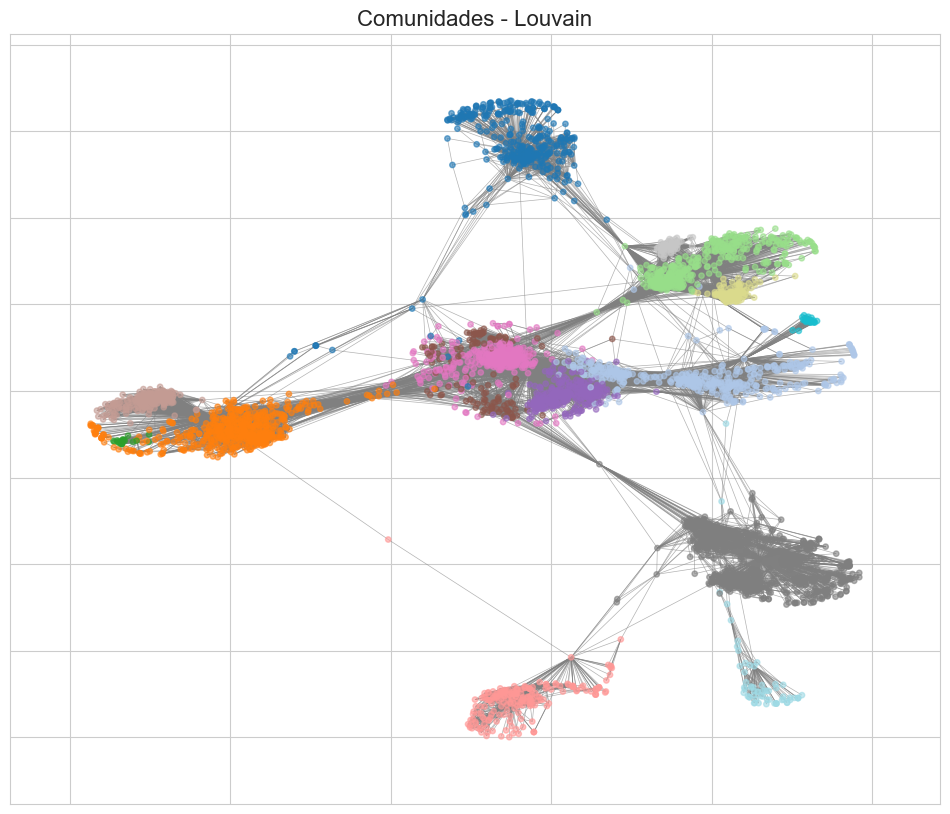


=== Executando Label Propagation ===
{'Algoritmo': 'Label Propagation', 'Tempo (s)': 0.269, 'Modularidade': 0.7368, 'Nº Comunidades': 44, 'Tamanho Médio': 91.8, 'Desvio Padrão': 210.85}


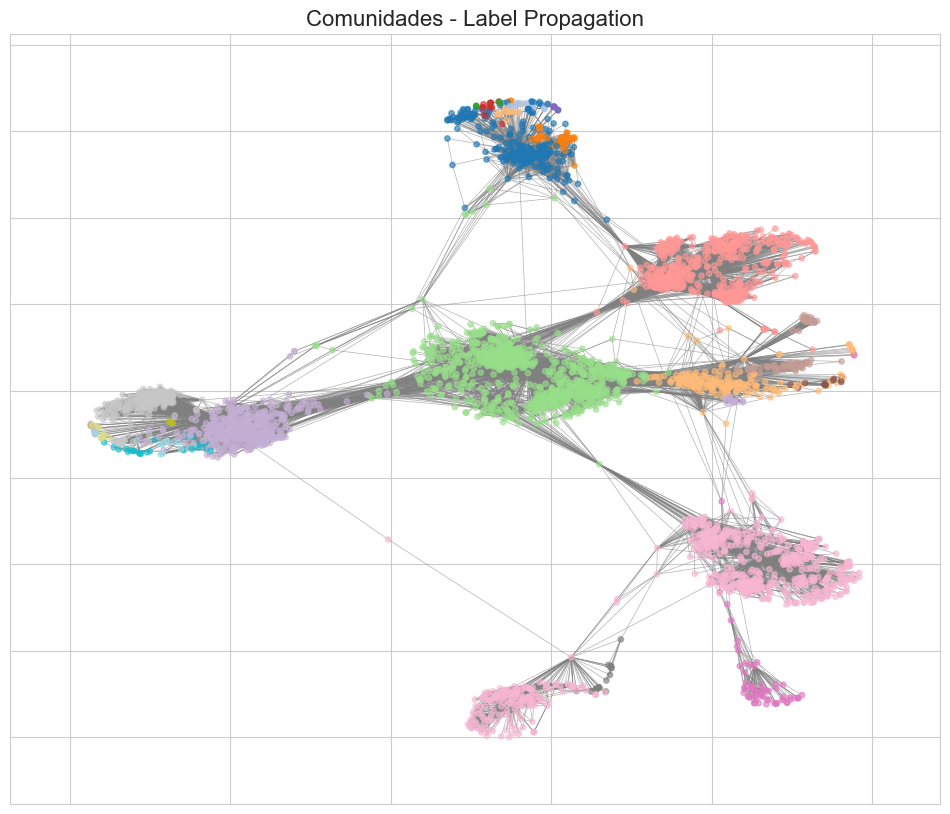


=== Executando Leiden ===
{'Algoritmo': 'Leiden', 'Tempo (s)': 0.0313, 'Modularidade': 0.8358, 'Nº Comunidades': 16, 'Tamanho Médio': 252.44, 'Desvio Padrão': 183.31}


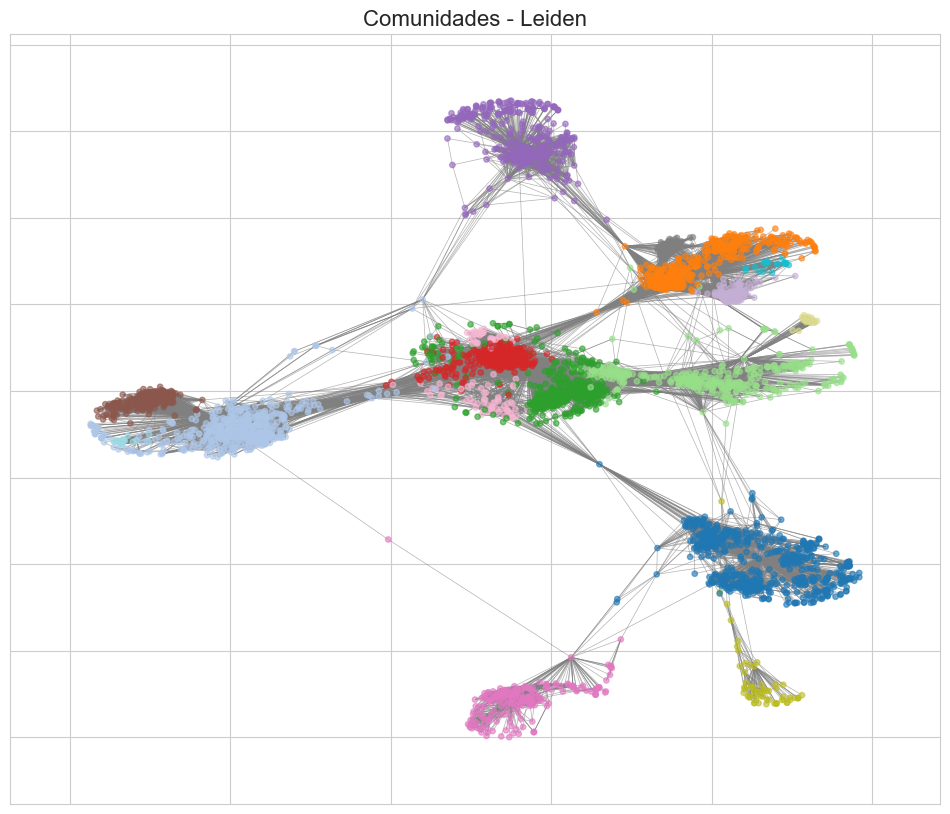


=== Comparação Inicial ===
           Algoritmo  Tempo (s)  Modularidade  Nº Comunidades  Tamanho Médio  \
0            Louvain     1.4563        0.8349              15         269.27   
1  Label Propagation     0.2690        0.7368              44          91.80   
2             Leiden     0.0313        0.8358              16         252.44   

   Desvio Padrão  
0         177.31  
1         210.85  
2         183.31  


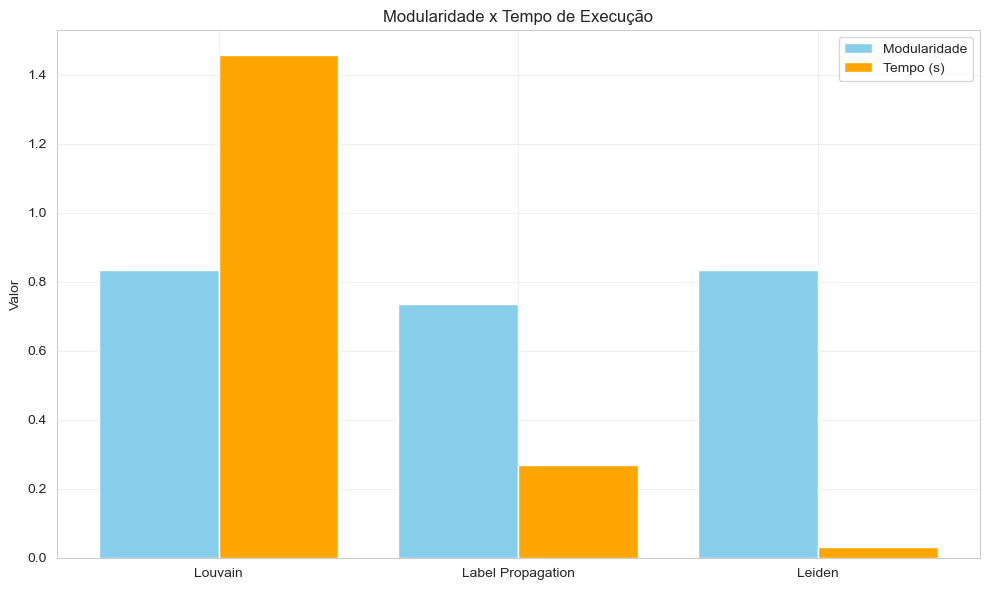

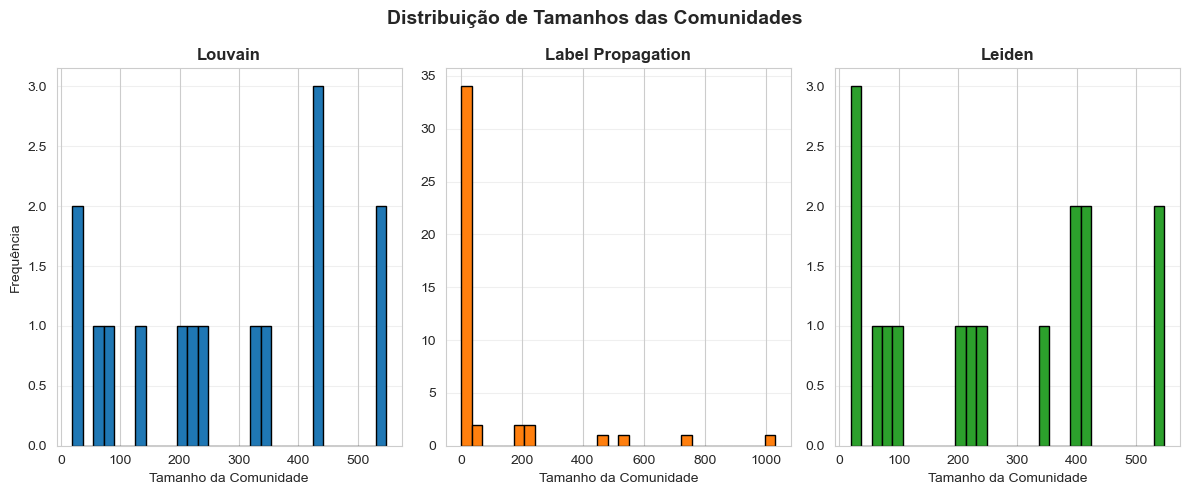

In [2]:
# =============================
# ANÁLISE COMPLETA: DETECÇÃO DE COMUNIDADES
# Rede Real vs Modelos de Referência (ATUALIZADO TCC)
# =============================

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import seaborn as sns  # Adicionado para os boxplots + stripplots
from community import community_louvain
from networkx.algorithms import community as nx_comm
import igraph as ig
import leidenalg

# Configuração de estilo para ficar "Acadêmico" (Fundo branco, grid suave)
sns.set_style("whitegrid")

# =============================
# PARTE 1: CARREGAMENTO E ANÁLISE INICIAL
# =============================

print("="*60)
print("PARTE 1: CARREGAMENTO E ANÁLISE INICIAL")
print("="*60)

# Carregar rede do Facebook
# Certifique-se que o arquivo está na pasta 'data/' ou ajuste o caminho
try:
    G_FB = nx.read_edgelist("data/facebook_combined.txt", create_using=nx.Graph(), nodetype=int)
except FileNotFoundError:
    print("ERRO: Arquivo 'data/facebook_combined.txt' não encontrado.")
    print("Por favor, verificar o caminho do arquivo.")
    # Criando um grafo dummy apenas para o código não quebrar se você for testar sem o arquivo
    G_FB = nx.erdos_renyi_graph(100, 0.05) 

print("\n=== Estatísticas da Rede do Facebook ===")
print("Número de nós:", G_FB.number_of_nodes())
print("Número de arestas:", G_FB.number_of_edges())
print("Grau médio:", round(sum(dict(G_FB.degree()).values()) / G_FB.number_of_nodes(), 2))

# Layout fixo para consistência visual
np.random.seed(42)
spring_pos = nx.spring_layout(G_FB, seed=42)

# =============================
# FUNÇÕES AUXILIARES
# =============================

def plot_communities(G, pos, partition, title, filename=None):
    """Gera a visualização colorida por comunidade."""
    unique_comms = set(partition.values())
    # Usando tab20 para ter cores distintas suficientes
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_comms)))
    node_colors = [colors[partition[node]] for node in G.nodes()]
    
    plt.figure(figsize=(12, 10))
    nx.draw_networkx(G, pos=pos, node_color=node_colors, node_size=15, 
                     with_labels=False, edge_color='gray', alpha=0.6, width=0.5)
    plt.title(title, fontsize=16)
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

def calculate_metrics(G, communities, algorithm_name, execution_time):
    """Calcula as métricas de desempenho das comunidades."""
    # Garante formato lista de sets
    if isinstance(communities, dict):
        communities = [set([k for k, v in communities.items() if v == c])
                      for c in set(communities.values())]
    
    modularity = nx_comm.modularity(G, communities)
    sizes = [len(c) for c in communities]
    
    return {
        "Algoritmo": algorithm_name,
        "Tempo (s)": round(execution_time, 4), # Aumentei precisão
        "Modularidade": round(modularity, 4),
        "Nº Comunidades": len(sizes),
        "Tamanho Médio": round(np.mean(sizes), 2),
        "Desvio Padrão": round(np.std(sizes), 2)
    }

# =============================
# PARTE 2: DETECÇÃO DE COMUNIDADES NA REDE REAL
# =============================

print("\n" + "="*60)
print("PARTE 2: DETECÇÃO DE COMUNIDADES NA REDE REAL")
print("="*60)

# 1. Louvain
print("\n=== Executando Louvain ===")
start = time.time()
partition_louvain = community_louvain.best_partition(G_FB)
louvain_time = time.time() - start
metrics_louvain = calculate_metrics(G_FB, partition_louvain, "Louvain", louvain_time)
print(metrics_louvain)
plot_communities(G_FB, spring_pos, partition_louvain, "Comunidades - Louvain", "Facebook_louvain.png")

# 2. Label Propagation
print("\n=== Executando Label Propagation ===")
start = time.time()
communities_lpa = list(nx_comm.label_propagation_communities(G_FB))
lpa_time = time.time() - start
partition_lpa = {node: i for i, comm in enumerate(communities_lpa) for node in comm}
metrics_lpa = calculate_metrics(G_FB, communities_lpa, "Label Propagation", lpa_time)
print(metrics_lpa)
plot_communities(G_FB, spring_pos, partition_lpa, "Comunidades - Label Propagation", "Facebook_lpa.png")

# 3. Leiden
print("\n=== Executando Leiden ===")
# Convertendo para igraph (necessário para o Leiden)
edges = list(G_FB.edges())
# Mapeamento de IDs para garantir consistência
nodes = list(G_FB.nodes())
node_map = {node: i for i, node in enumerate(nodes)}
edges_mapped = [(node_map[u], node_map[v]) for u, v in edges]

G_ig = ig.Graph(len(nodes), edges_mapped)
start = time.time()
partition_leiden = leidenalg.find_partition(G_ig, leidenalg.ModularityVertexPartition)
leiden_time = time.time() - start

# Convertendo de volta para formato NetworkX/Dict
partition_leiden_nx = {}
for i, comm in enumerate(partition_leiden):
    for node_idx in comm:
        partition_leiden_nx[nodes[node_idx]] = i

communities_leiden = [set([k for k, v in partition_leiden_nx.items() if v == c]) 
                      for c in set(partition_leiden_nx.values())]

metrics_leiden = calculate_metrics(G_FB, communities_leiden, "Leiden", leiden_time)
print(metrics_leiden)
plot_communities(G_FB, spring_pos, partition_leiden_nx, "Comunidades - Leiden", "Facebook_leiden.png")

# Comparação inicial
print("\n=== Comparação Inicial ===")
results = pd.DataFrame([metrics_louvain, metrics_lpa, metrics_leiden])
print(results)

# Gráfico comparativo: Modularidade x Tempo
plt.figure(figsize=(10, 6))
x = range(len(results))
plt.bar(x, results["Modularidade"], width=0.4, label="Modularidade", color="skyblue")
plt.bar([i + 0.4 for i in x], results["Tempo (s)"], width=0.4, label="Tempo (s)", color="orange")
plt.xticks([i + 0.2 for i in x], results["Algoritmo"])
plt.ylabel("Valor")
plt.title("Modularidade x Tempo de Execução")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Facebook_comparacao_modularidade_tempo.png", dpi=300)
plt.show()

# Histograma de tamanhos das comunidades
plt.figure(figsize=(12, 5))
for i, (nome, part) in enumerate([
    ("Louvain", partition_louvain),
    ("Label Propagation", partition_lpa),
    ("Leiden", partition_leiden_nx)
]):
    sizes = [list(part.values()).count(c) for c in set(part.values())]
    plt.subplot(1, 3, i+1)
    plt.hist(sizes, bins=30, color=plt.cm.tab10(i), edgecolor='black')
    plt.title(nome, fontweight='bold')
    plt.xlabel("Tamanho da Comunidade")
    if i == 0:
        plt.ylabel("Frequência")
    plt.grid(True, alpha=0.3, axis='y')
plt.suptitle("Distribuição de Tamanhos das Comunidades", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Facebook_distribuicao_comunidades.png", dpi=300)
plt.show()


PARTE 3: COMPARAÇÃO COM MODELOS DE REFERÊNCIA

GERANDO VISUALIZAÇÃO DE EXEMPLOS E TABELA DE PARÂMETROS
✓ Tabela de parâmetros salva: tabela_parametros_experimento.csv
                 Modelo  N (Nós) E (Arestas) Parâmetro Principal                                       Justificativa
0  Rede Real (Facebook)     4039       88234                   -                             Dados observados (SNAP)
1           Erdős-Rényi     4039      ~88234         p = 0.01082                     Mantém a densidade da rede real
2       Barabási-Albert     4039      ~88234              m = 21    Baseado no grau médio (crescimento preferencial)
3        Watts-Strogatz     4039      ~88234     k = 44, p = 0.3  k próximo ao grau médio; p padrão para Small-World

Gerando instâncias de exemplo para plotagem...


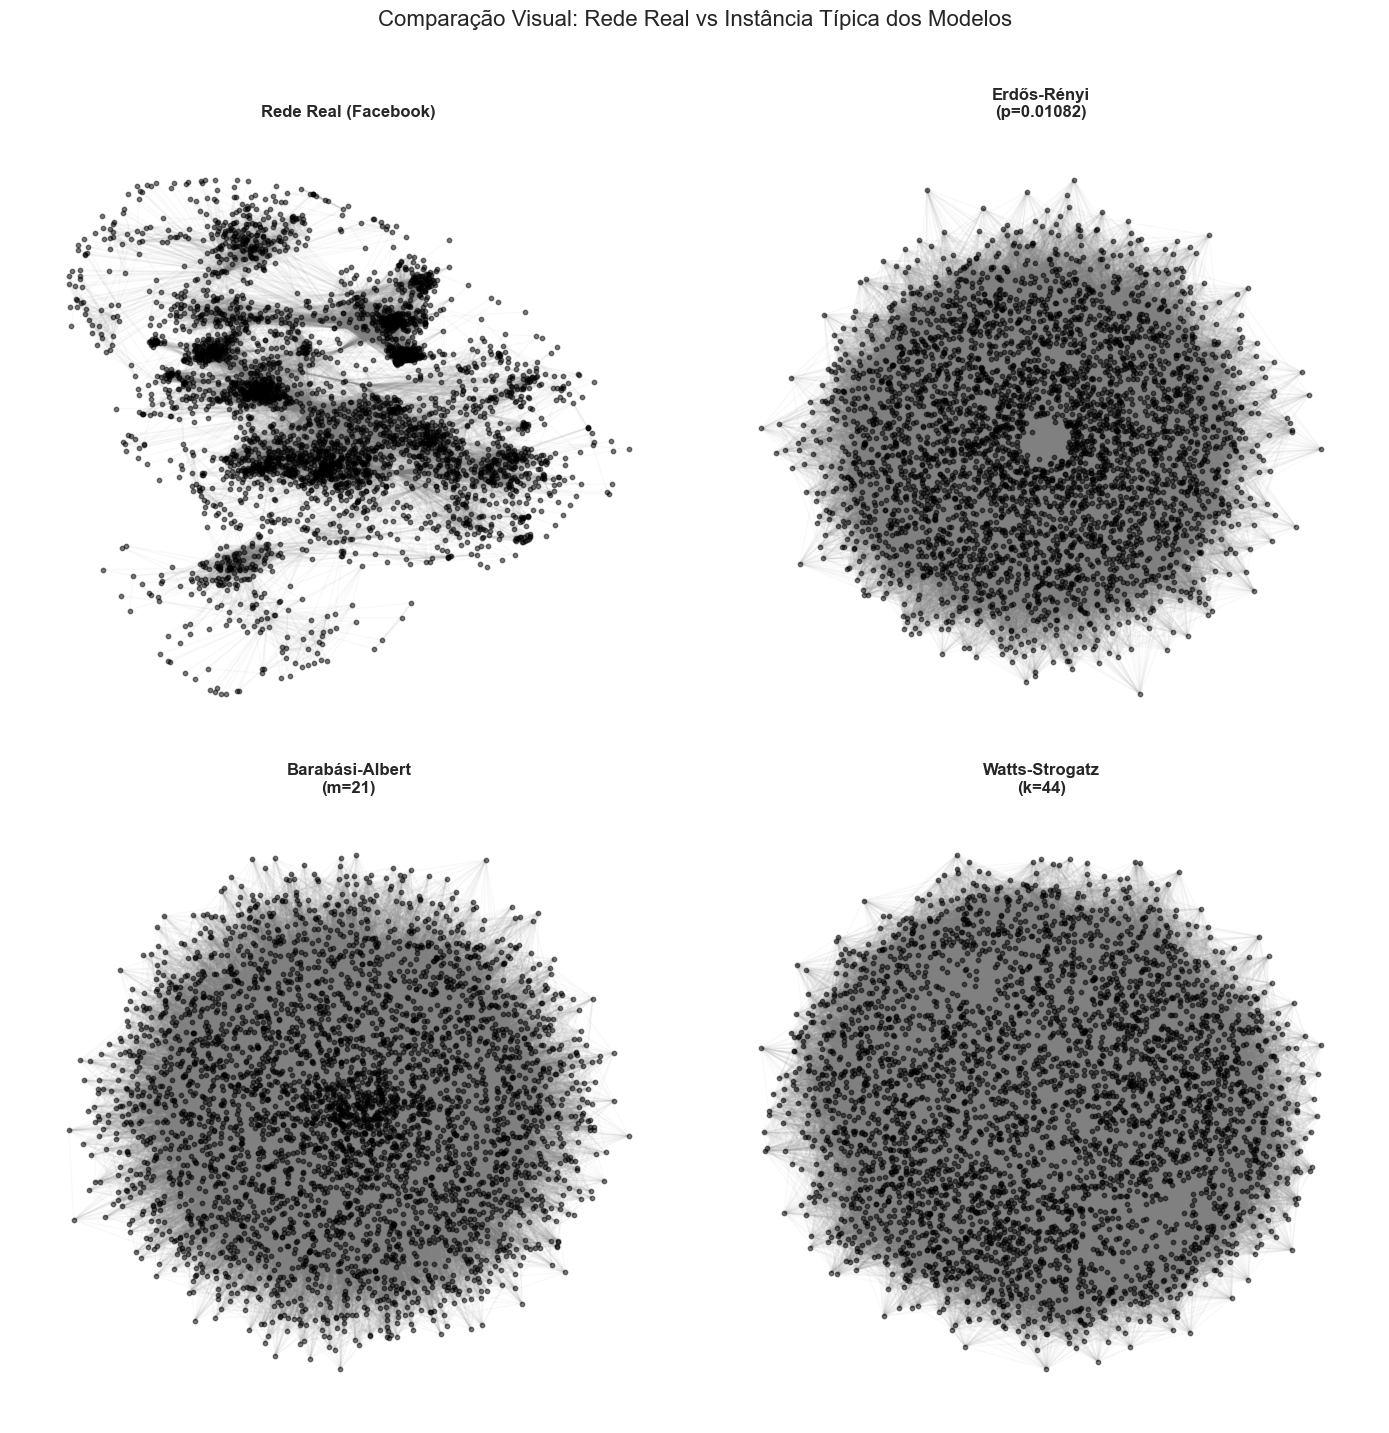

✓ Figura explicativa salva: comparacao_visual_modelos.png

ANÁLISE: Louvain (Gerando 30 experimentos por modelo...)
  Parâmetros calculados dinamicamente:
  - Erdős-Rényi: N=4039, p=0.01082
  - Barabási-Albert: N=4039, m=21
  - Watts-Strogatz: N=4039, k=44, p=0.3


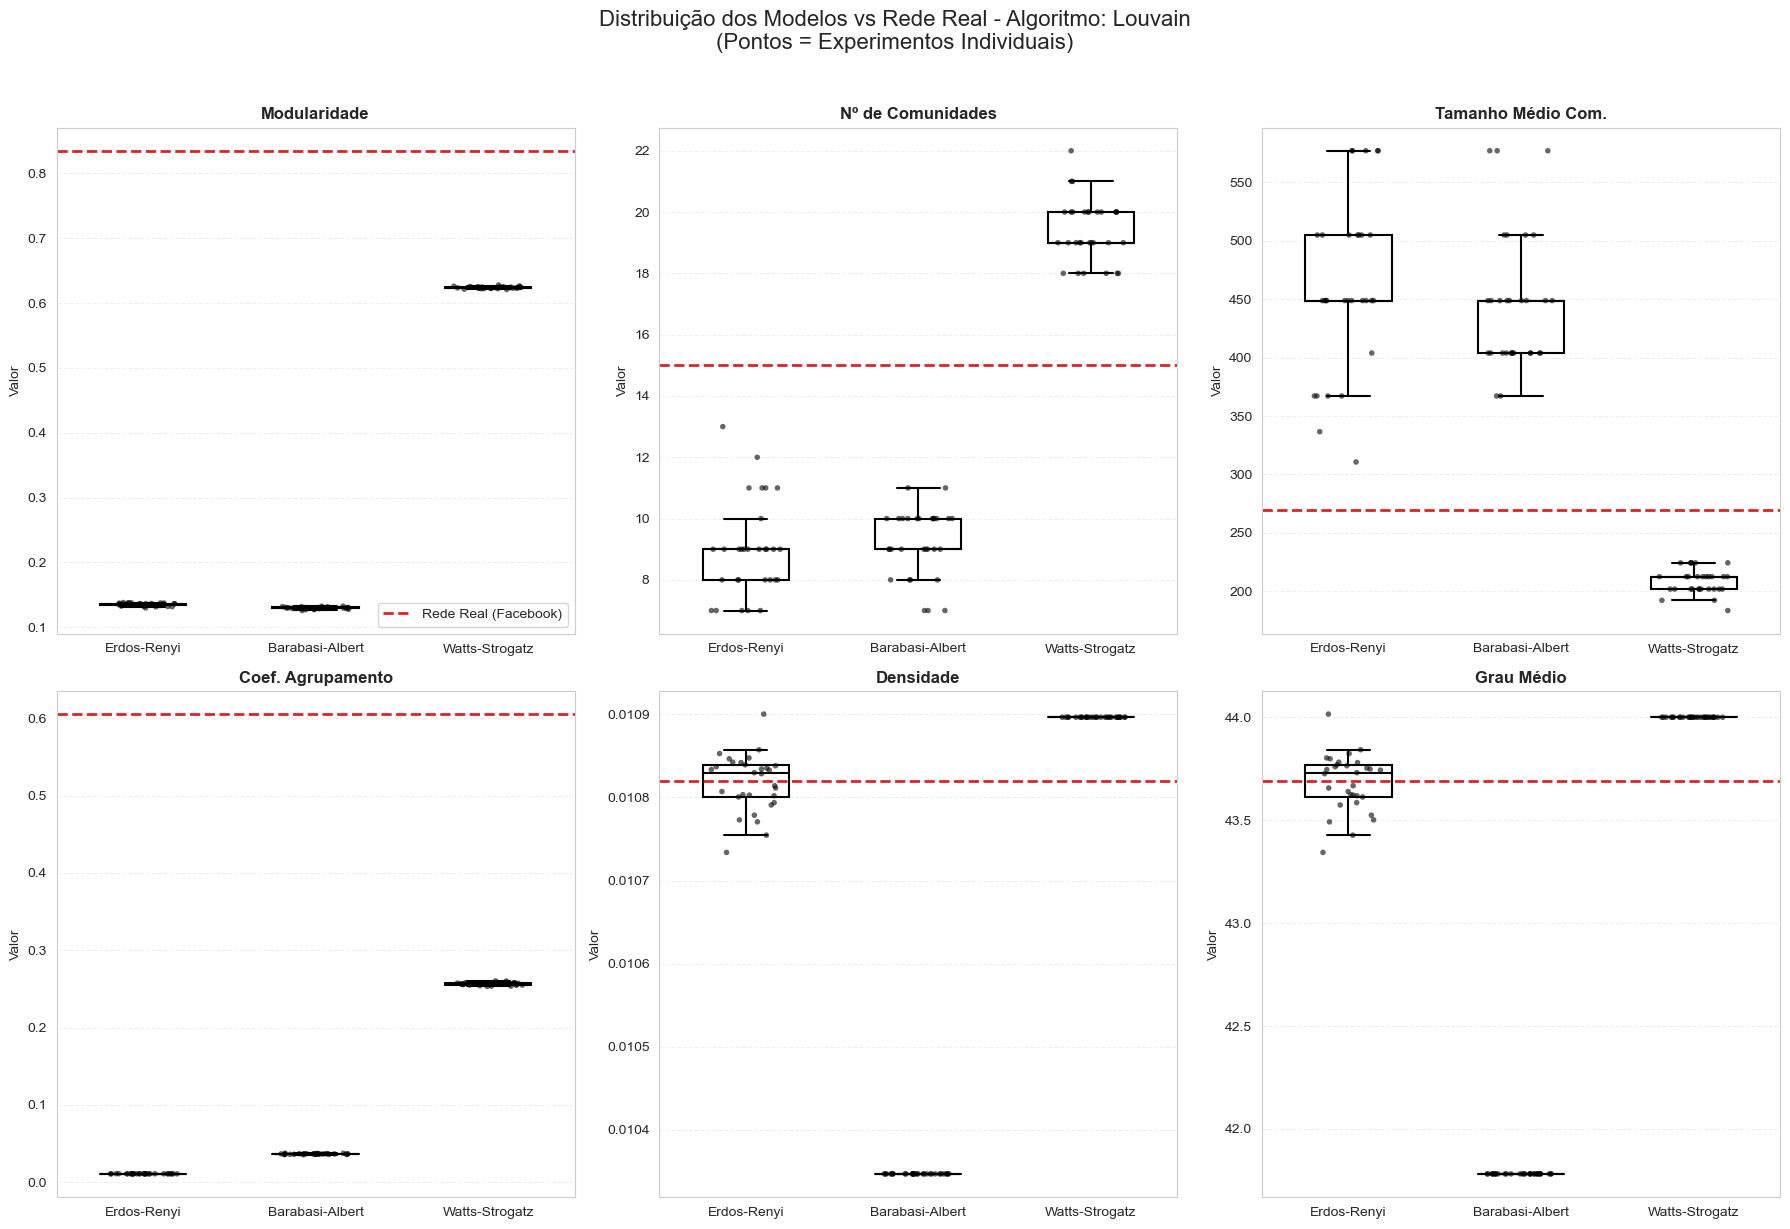

✓ Gráfico salvo: boxplot_stripplot_Louvain.png

ANÁLISE: Label Propagation (Gerando 30 experimentos por modelo...)
  Parâmetros calculados dinamicamente:
  - Erdős-Rényi: N=4039, p=0.01082
  - Barabási-Albert: N=4039, m=21
  - Watts-Strogatz: N=4039, k=44, p=0.3


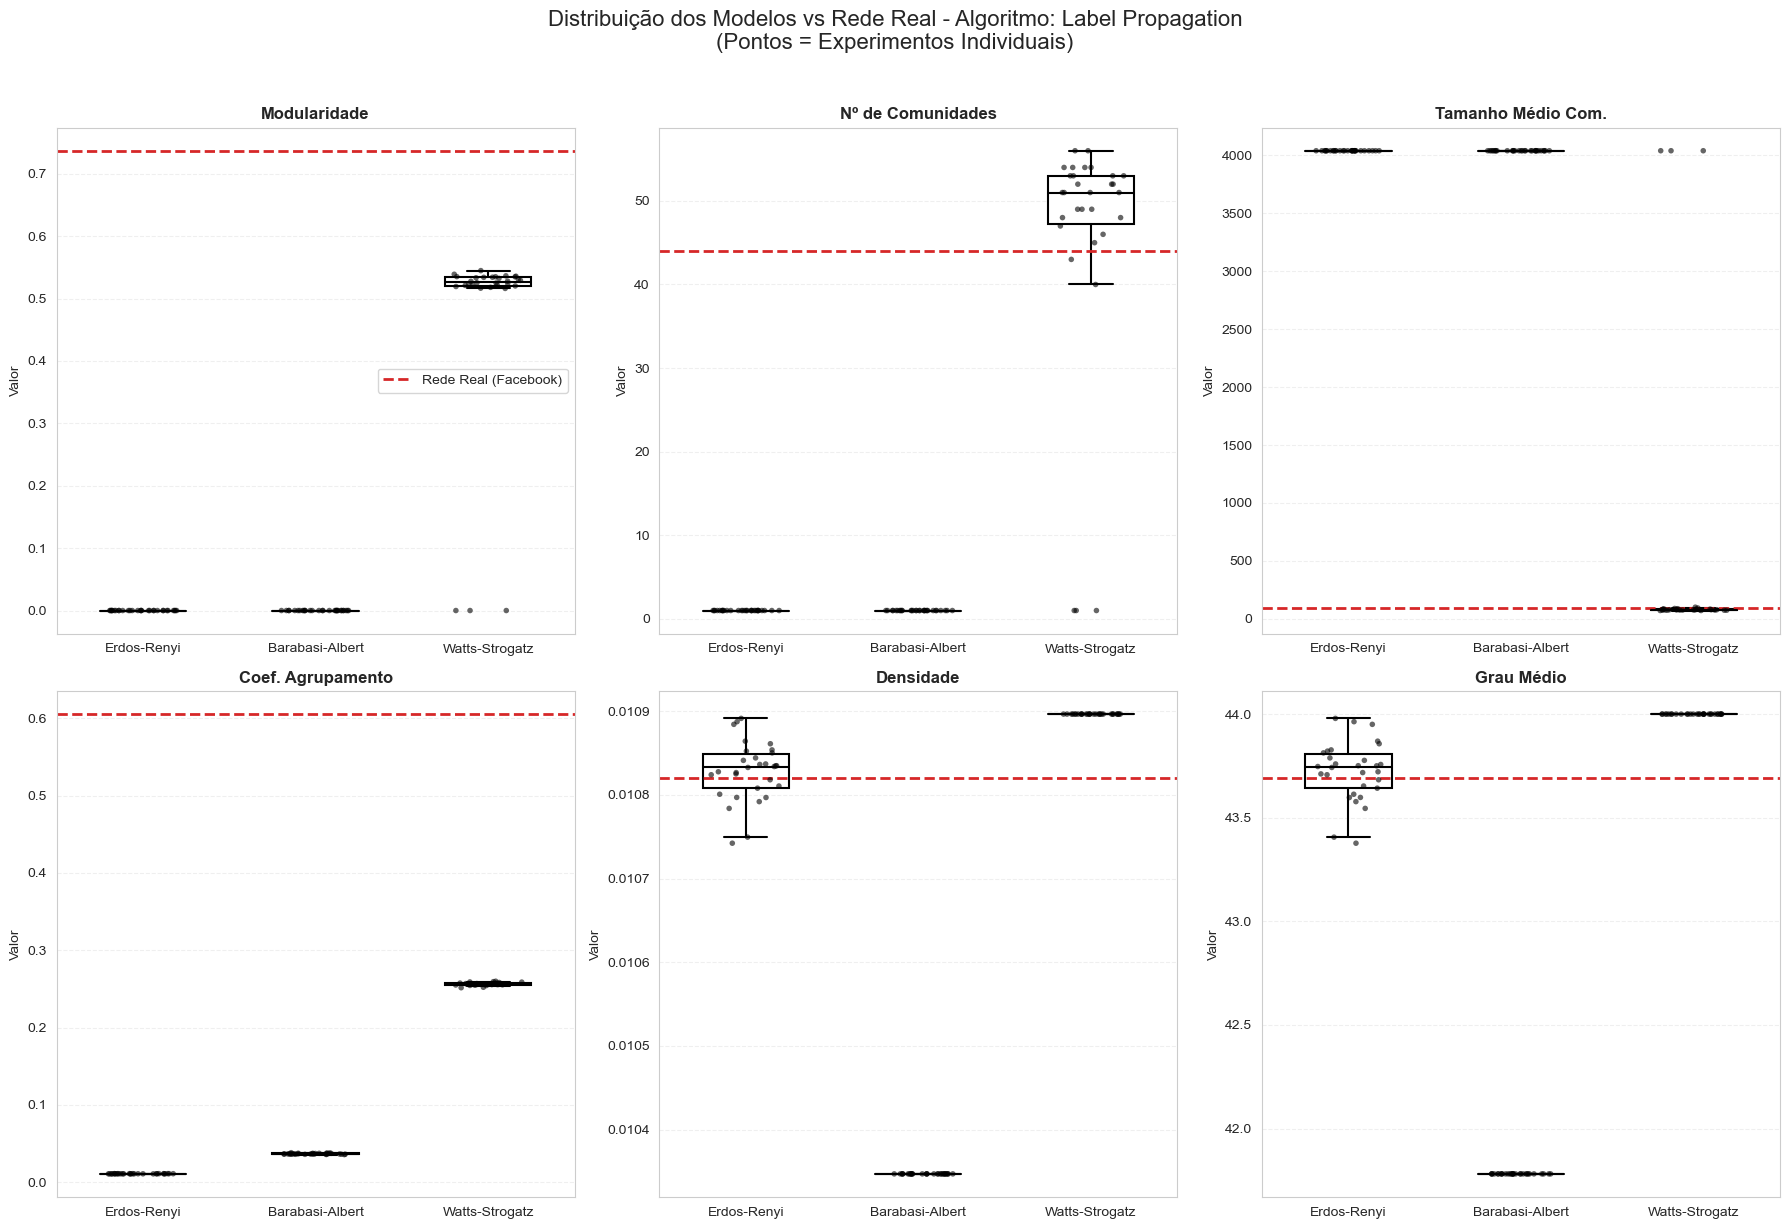

✓ Gráfico salvo: boxplot_stripplot_Label_Propagation.png

ANÁLISE: Leiden (Gerando 30 experimentos por modelo...)
  Parâmetros calculados dinamicamente:
  - Erdős-Rényi: N=4039, p=0.01082
  - Barabási-Albert: N=4039, m=21
  - Watts-Strogatz: N=4039, k=44, p=0.3


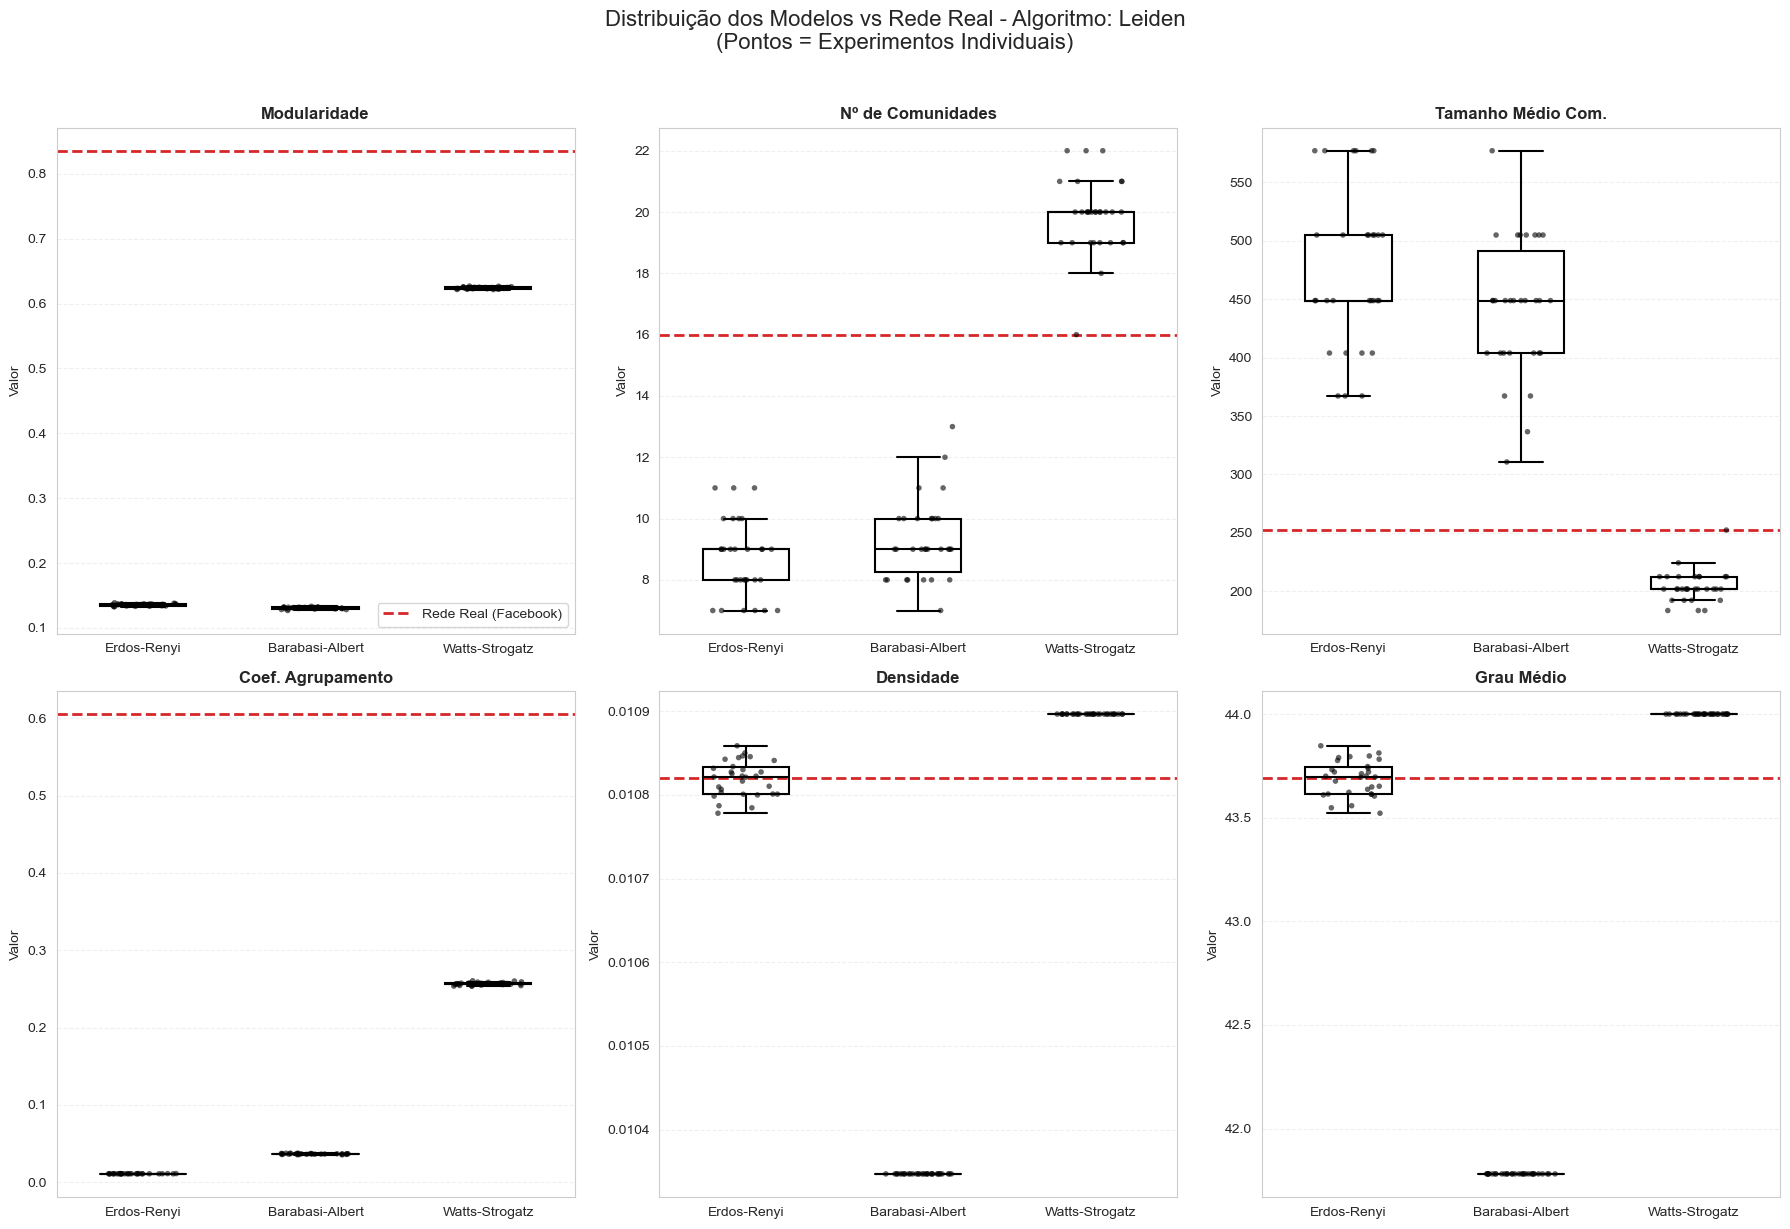

✓ Gráfico salvo: boxplot_stripplot_Leiden.png

PROCESSAMENTO FINALIZADO COM SUCESSO
Verifique os arquivos PNG gerados na pasta.


In [3]:
# =============================
# PARTE 3: COMPARAÇÃO COM MODELOS DE REFERÊNCIA
# =============================
print("\n" + "="*80)
print("PARTE 3: COMPARAÇÃO COM MODELOS DE REFERÊNCIA")
print("="*80)

def calcular_metricas_comunidades(G, partition_dict, algorithm_name):
    """Calcula métricas de comunidades para um grafo"""
    metricas = {}
    
    communities = [set([k for k, v in partition_dict.items() if v == c])
                   for c in set(partition_dict.values())]
    
    metricas['algoritmo'] = algorithm_name
    metricas['modularidade'] = nx_comm.modularity(G, communities)
    metricas['num_comunidades'] = len(communities)
    
    sizes = [len(c) for c in communities]
    metricas['tamanho_medio'] = np.mean(sizes) if sizes else 0
    metricas['tamanho_std'] = np.std(sizes) if sizes else 0
    
    # Métricas topológicas básicas
    metricas['coef_agrupamento'] = nx.average_clustering(G)
    metricas['densidade'] = nx.density(G)
    metricas['grau_medio'] = np.mean([d for n, d in G.degree()])
    
    return metricas

def executar_algoritmo_em_grafo(G, algorithm_name):
    """Executa um algoritmo de detecção de comunidades em um grafo arbitrário"""
    if algorithm_name == "Louvain":
        partition = community_louvain.best_partition(G)
        
    elif algorithm_name == "Label Propagation":
        communities = list(nx_comm.label_propagation_communities(G))
        partition = {node: i for i, comm in enumerate(communities) for node in comm}
        
    elif algorithm_name == "Leiden":
        # Conversão rápida para igraph
        nodes_list = list(G.nodes())
        if not nodes_list: return {}
        node_map = {n: i for i, n in enumerate(nodes_list)}
        edges = [(node_map[u], node_map[v]) for u, v in G.edges()]
        G_ig = ig.Graph(len(nodes_list), edges)
        
        part = leidenalg.find_partition(G_ig, leidenalg.ModularityVertexPartition)
        partition = {}
        for i, comm in enumerate(part):
            for node_idx in comm:
                partition[nodes_list[node_idx]] = i
                
    return partition

def analisar_algoritmo_vs_modelos(G_real, partition_real, algorithm_name, n_experimentos=30):
    """
    Gera modelos sintéticos com parâmetros baseados na rede real e compara.
    ATENÇÃO OBS: Aqui está a justificativa dos parâmetros para o texto.
    """
    print(f"\nANÁLISE: {algorithm_name} (Gerando 30 experimentos por modelo...)")
    
    n_nodes = G_real.number_of_nodes()
    n_edges = G_real.number_of_edges()
    
    # --- CÁLCULO DOS PARÂMETROS (Explicar isso na metodologia) ---
    # 1. Erdős-Rényi: Probabilidade p para manter a mesma densidade da rede real.
    # Fórmula: p = 2 * E / (N * (N-1))
    p_er = (2 * n_edges) / (n_nodes * (n_nodes - 1))
    
    # 2. Barabási-Albert: m = número de arestas que cada novo nó conecta.
    # Fórmula: m ~ E / N (grau médio / 2 aprox)
    m_ba = int(n_edges / n_nodes)
    if m_ba < 1: m_ba = 1
    
    # 3. Watts-Strogatz: k vizinhos próximos e prob p de reconexão.
    # k deve ser próximo ao grau médio.
    k_ws = int(2 * n_edges / n_nodes)
    if k_ws % 2 != 0: k_ws += 1 # k deve ser par
    p_ws = 0.3 # Padrão para small-world
    
    print(f"  Parâmetros calculados dinamicamente:")
    print(f"  - Erdős-Rényi: N={n_nodes}, p={p_er:.5f}")
    print(f"  - Barabási-Albert: N={n_nodes}, m={m_ba}")
    print(f"  - Watts-Strogatz: N={n_nodes}, k={k_ws}, p={p_ws}")
    
    resultados = {'Erdos-Renyi': [], 'Barabasi-Albert': [], 'Watts-Strogatz': []}
    
    for i in range(n_experimentos):
        # Gerar grafos e rodar algoritmo
        try:
            # ER
            G_er = nx.erdos_renyi_graph(n_nodes, p_er)
            p_er_part = executar_algoritmo_em_grafo(G_er, algorithm_name)
            resultados['Erdos-Renyi'].append(calcular_metricas_comunidades(G_er, p_er_part, algorithm_name))
            
            # BA
            G_ba = nx.barabasi_albert_graph(n_nodes, m_ba)
            p_ba_part = executar_algoritmo_em_grafo(G_ba, algorithm_name)
            resultados['Barabasi-Albert'].append(calcular_metricas_comunidades(G_ba, p_ba_part, algorithm_name))
            
            # WS
            G_ws = nx.watts_strogatz_graph(n_nodes, k_ws, p_ws)
            p_ws_part = executar_algoritmo_em_grafo(G_ws, algorithm_name)
            resultados['Watts-Strogatz'].append(calcular_metricas_comunidades(G_ws, p_ws_part, algorithm_name))
            
        except Exception as e:
            print(f"Erro iter {i}: {e}")

    metricas_real = calcular_metricas_comunidades(G_real, partition_real, algorithm_name)
    return metricas_real, resultados

# =============================
# NOVA FUNÇÃO DE PLOTAGEM (ATUALIZADA)
# =============================

def criar_boxplots_atualizados(metricas_real, experimentos, algorithm_name):
    """
    BOX PLOTS: combinados com Stripplots (bolinhas) usando Seaborn (Cada bolinha um grafo. 
    Mostram a DISPERSÃO dos valores das métricas nos modelos sintéticos.
    A Linha mostra onde a REDE REAL se posiciona.
    
    INTERPRETAÇÃO:
    - Se a linha está DENTRO da caixa: rede real é típica desse modelo
    - Se está FORA: rede real tem comportamento diferente do modelo
    - Caixas pequenas = modelo consistente; grandes = alta variabilidade
    """
    
    metricas_para_plotar = [
        ('modularidade', 'Modularidade'), 
        ('num_comunidades', 'Nº de Comunidades'), 
        ('tamanho_medio', 'Tamanho Médio Com.'),
        ('coef_agrupamento', 'Coef. Agrupamento'), 
        ('densidade', 'Densidade'), 
        ('grau_medio', 'Grau Médio')
    ]
    
    # Configurar layout de subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, (metrica_key, metrica_titulo) in enumerate(metricas_para_plotar):
        ax = axes[idx]
        
        # 1. Preparar dados para o Seaborn (Formato Longo)
        data_list = []
        for modelo in ['Erdos-Renyi', 'Barabasi-Albert', 'Watts-Strogatz']:
            if modelo in experimentos:
                vals = [exp[metrica_key] for exp in experimentos[modelo]]
                for v in vals:
                    data_list.append({'Modelo': modelo, 'Valor': v})
        
        df_plot = pd.DataFrame(data_list)
        
        # 2. BOXPLOT (Camada inferior) - Estilo Clean/P&B
        # CORREÇÃO: Removemos 'linecolor' que causava o erro.
        sns.boxplot(x='Modelo', y='Valor', data=df_plot, ax=ax,
                    color='white',       # Interior branco
                    linewidth=1.5,       # Espessura das linhas
                    width=0.5,
                    showfliers=False,    # Esconde outliers do boxplot
                    boxprops=dict(edgecolor='black'),    # Cor da borda da caixa
                    whiskerprops=dict(color='black'),    # Cor dos "bigodes"
                    capprops=dict(color='black'),        # Cor das tampas
                    medianprops=dict(color='black'))     # Cor da mediana
        
        # 3. STRIPPLOT (As "bolinhas" pedidas pelo orientador) - Camada superior
        sns.stripplot(x='Modelo', y='Valor', data=df_plot, ax=ax,
                      color='black',       # Pontos pretos/cinza escuro
                      alpha=0.6,           # Transparência para ver sobreposição
                      jitter=0.2,          # Espalhamento horizontal
                      size=4)              # Tamanho da bolinha
        
        # 4. REDE REAL (Estrela em destaque)
        valor_real = metricas_real[metrica_key]
        
        # Linha horizontal tracejada vermelha
        ax.axhline(y=valor_real, color='#D62728', linestyle='--', linewidth=2, label='Rede Real (Facebook)')
        
        # Estilização do gráfico
        ax.set_title(metrica_titulo, fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Valor')
        ax.grid(True, axis='y', alpha=0.3, linestyle='--')
        
        if idx == 0:
            ax.legend(loc='best', frameon=True)
            
    plt.suptitle(f'Distribuição dos Modelos vs Rede Real - Algoritmo: {algorithm_name}\n(Pontos = Experimentos Individuais)', fontsize=16, y=1.02)
    plt.tight_layout()
    
    filename = f'boxplot_stripplot_{algorithm_name.replace(" ", "_")}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Gráfico salvo: {filename}")


# =============================
# VISUALIZAÇÃO DO PROCESSO + TABELA DE PARÂMETROS
# =============================

def visualizar_exemplos_modelos(G_real):
    """
    1. Gera e visualiza UMA instância de cada modelo.
    2. Salva uma TABELA (CSV) com os parâmetros exatos usados.
    """
    print("\n" + "="*80)
    print("GERANDO VISUALIZAÇÃO DE EXEMPLOS E TABELA DE PARÂMETROS")
    print("="*80)

    n_nodes = G_real.number_of_nodes()
    n_edges = G_real.number_of_edges()
    grau_medio_real = np.mean([d for n, d in G_real.degree()])
    densidade_real = nx.density(G_real)
    
    # --- CÁLCULO DOS PARÂMETROS ---
    # 1. Erdős-Rényi
    p_er = (2 * n_edges) / (n_nodes * (n_nodes - 1))
    
    # 2. Barabási-Albert
    m_ba = int(n_edges / n_nodes)
    if m_ba < 1: m_ba = 1
    
    # 3. Watts-Strogatz
    k_ws = int(2 * n_edges / n_nodes)
    if k_ws % 2 != 0: k_ws += 1
    p_ws = 0.3

    # --- SALVAR TABELA DE PARÂMETROS (O que o orientador pediu) ---
    dados_tabela = [
        {
            "Modelo": "Rede Real (Facebook)",
            "N (Nós)": n_nodes,
            "E (Arestas)": n_edges,
            "Parâmetro Principal": "-",
            "Justificativa": "Dados observados (SNAP)"
        },
        {
            "Modelo": "Erdős-Rényi",
            "N (Nós)": n_nodes,
            "E (Arestas)": f"~{n_edges}",
            "Parâmetro Principal": f"p = {p_er:.5f}",
            "Justificativa": "Mantém a densidade da rede real"
        },
        {
            "Modelo": "Barabási-Albert",
            "N (Nós)": n_nodes,
            "E (Arestas)": f"~{n_edges}",
            "Parâmetro Principal": f"m = {m_ba}",
            "Justificativa": "Baseado no grau médio (crescimento preferencial)"
        },
        {
            "Modelo": "Watts-Strogatz",
            "N (Nós)": n_nodes,
            "E (Arestas)": f"~{n_edges}",
            "Parâmetro Principal": f"k = {k_ws}, p = {p_ws}",
            "Justificativa": "k próximo ao grau médio; p padrão para Small-World"
        }
    ]
    
    df_params = pd.DataFrame(dados_tabela)
    df_params.to_csv("tabela_parametros_experimento.csv", index=False, sep=';')
    print("✓ Tabela de parâmetros salva: tabela_parametros_experimento.csv")
    print(df_params.to_string()) # Mostra no console também

    # --- GERAÇÃO DOS GRAFOS PARA VISUALIZAÇÃO ---
    print("\nGerando instâncias de exemplo para plotagem...")
    G_er = nx.erdos_renyi_graph(n_nodes, p_er, seed=42)
    G_ba = nx.barabasi_albert_graph(n_nodes, m_ba, seed=42)
    G_ws = nx.watts_strogatz_graph(n_nodes, k_ws, p_ws, seed=42)

    grafos = [
        ("Rede Real (Facebook)", G_real),
        (f"Erdős-Rényi\n(p={p_er:.5f})", G_er),
        (f"Barabási-Albert\n(m={m_ba})", G_ba),
        (f"Watts-Strogatz\n(k={k_ws})", G_ws)
    ]

    # Configurar a figura (2x2)
    fig, axes = plt.subplots(2, 2, figsize=(14, 14))
    axes = axes.flatten()
    
    for idx, (titulo, G) in enumerate(grafos):
        ax = axes[idx]
        # Usando layout circular ou spring com poucas iterações para ser rápido
        pos = nx.spring_layout(G, iterations=15, seed=42) 
        
        nx.draw_networkx_nodes(G, pos, node_size=10, node_color='black', alpha=0.5, ax=ax)
        nx.draw_networkx_edges(G, pos, alpha=0.05, edge_color='gray', ax=ax)
        
        grau = np.mean([d for n, d in G.degree()])
        
        ax.set_title(titulo, fontsize=12, fontweight='bold')
        ax.set_xlabel(f"Grau Médio Observado: {grau:.2f}")
        ax.axis('off')

    plt.suptitle("Comparação Visual: Rede Real vs Instância Típica dos Modelos", fontsize=16, y=1.02)
    plt.tight_layout()
    
    filename = "comparacao_visual_modelos.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Figura explicativa salva: {filename}")


# =============================
# EXECUTAR ANÁLISES
# =============================

# --- CHAMADA DA FUNÇÃO ---
# Chame esta função UMA VEZ antes de começar os loops de análise
visualizar_exemplos_modelos(G_FB)

algoritmos_analise = [
    ("Louvain", partition_louvain),
    ("Label Propagation", partition_lpa),
    ("Leiden", partition_leiden_nx)
]

# Dicionário para guardar tudo se precisar depois
resultados_completos = {}

for algorithm_name, partition in algoritmos_analise:
    # 1. Gerar dados (Demora um pouco pois roda 30x cada modelo)
    metricas_real, experimentos = analisar_algoritmo_vs_modelos(
        G_FB, partition, algorithm_name, n_experimentos=30
    )
    
    # 2. Gerar Gráficos Atualizados (Seaborn)
    criar_boxplots_atualizados(metricas_real, experimentos, algorithm_name)
    
    resultados_completos[algorithm_name] = {
        'real': metricas_real,
        'modelos': experimentos
    }

print("\n" + "="*80)
print("PROCESSAMENTO FINALIZADO COM SUCESSO")
print("Verifique os arquivos PNG gerados na pasta.")
print("="*80)


PARTE 4: GRÁFICOS COMPARATIVOS DE MÉTRICAS

OBJETIVO: Visualizar DIFERENÇAS ABSOLUTAS entre REDE REAL e MODELOS SINTÉTICOS.

GRÁFICO DE BARRAS:
- Barra azul = Rede Real (Facebook)
- Barras coloridas = Média dos modelos sintéticos (30 experimentos cada)
- Barras de erro = Desvio padrão (mostram variabilidade)

INTERPRETAÇÃO:
- Se barras Real e Modelo têm altura similar: comportamento parecido
- Se Real >> Modelo: rede real tem essa propriedade mais forte
- Se Real << Modelo: rede real tem essa propriedade mais fraca
- Barras de erro grandes: modelo inconsistente



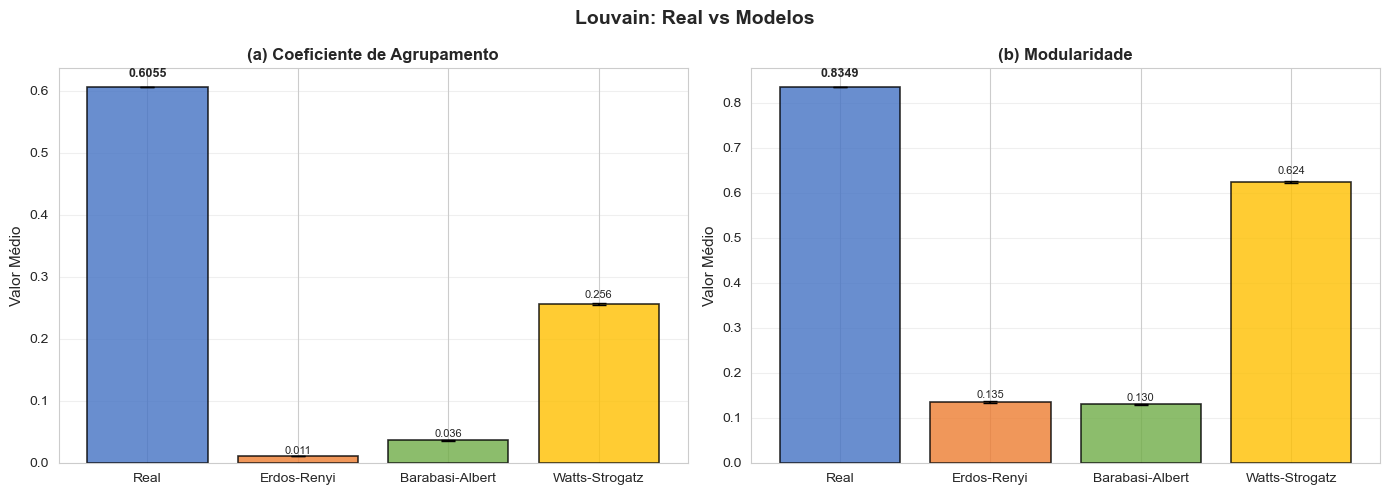

✓ Gráfico salvo: Rede Real (azul) vs Modelos (colorido)


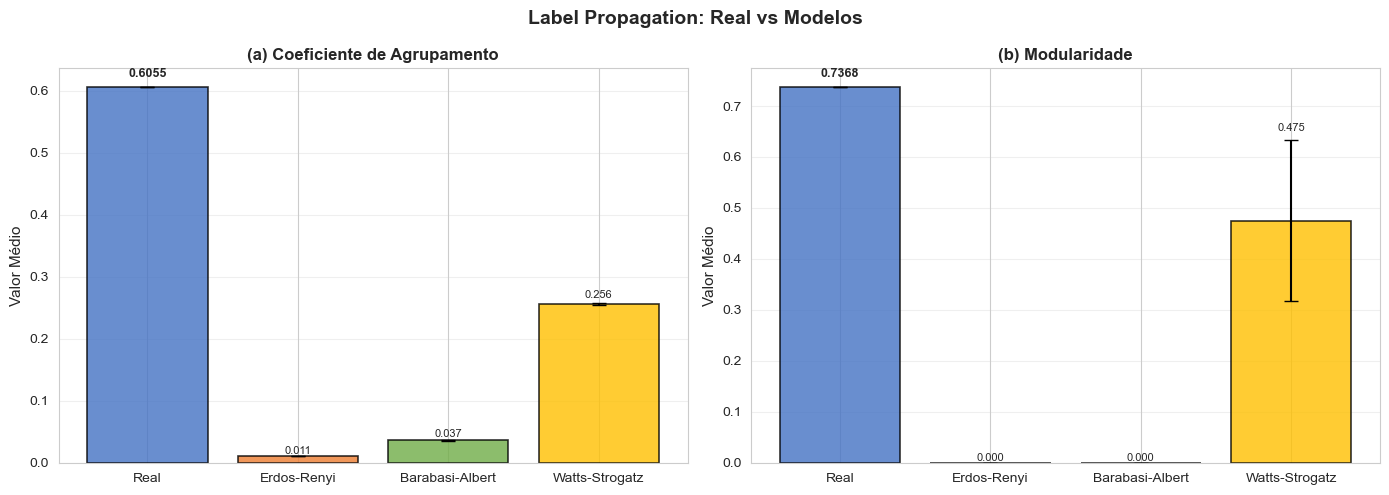

✓ Gráfico salvo: Rede Real (azul) vs Modelos (colorido)


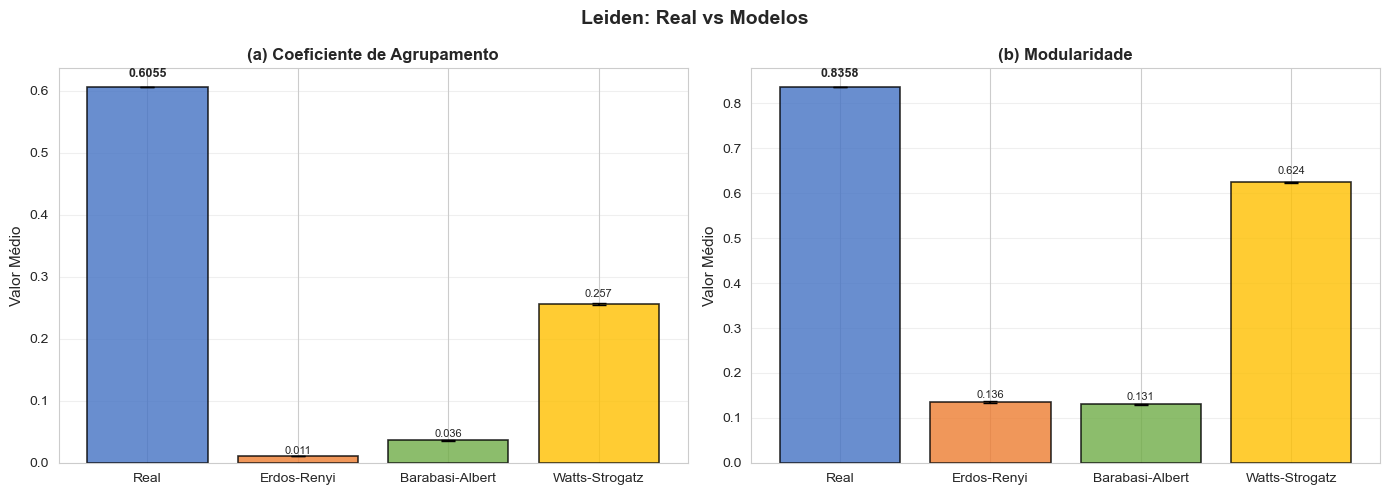

✓ Gráfico salvo: Rede Real (azul) vs Modelos (colorido)


In [4]:
# =============================
# PARTE 4: GRÁFICOS COMPARATIVOS DE MÉTRICAS
# =============================

print("\n" + "="*80)
print("PARTE 4: GRÁFICOS COMPARATIVOS DE MÉTRICAS")
print("="*80)
print("""
OBJETIVO: Visualizar DIFERENÇAS ABSOLUTAS entre REDE REAL e MODELOS SINTÉTICOS.

GRÁFICO DE BARRAS:
- Barra azul = Rede Real (Facebook)
- Barras coloridas = Média dos modelos sintéticos (30 experimentos cada)
- Barras de erro = Desvio padrão (mostram variabilidade)

INTERPRETAÇÃO:
- Se barras Real e Modelo têm altura similar: comportamento parecido
- Se Real >> Modelo: rede real tem essa propriedade mais forte
- Se Real << Modelo: rede real tem essa propriedade mais fraca
- Barras de erro grandes: modelo inconsistente
""")

def criar_graficos_comparativos_metricas(resultados_completos):
    """Cria gráficos de barras comparando Real vs Modelos"""
    
    for algorithm_name in ["Louvain", "Label Propagation", "Leiden"]:
        metricas_real = resultados_completos[algorithm_name]['real']
        experimentos = resultados_completos[algorithm_name]['modelos']
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        metricas_plot = ['coef_agrupamento', 'modularidade']
        titulos = ['(a) Coeficiente de Agrupamento', '(b) Modularidade']
        
        for idx, (metrica, titulo) in enumerate(zip(metricas_plot, titulos)):
            ax = axes[idx]
            
            labels = ['Real', 'Erdos-Renyi', 'Barabasi-Albert', 'Watts-Strogatz']
            valores = [metricas_real[metrica]]
            erros = [0]
            
            for modelo in ['Erdos-Renyi', 'Barabasi-Albert', 'Watts-Strogatz']:
                vals = [exp[metrica] for exp in experimentos[modelo]]
                valores.append(np.mean(vals))
                erros.append(np.std(vals))
            
            cores = ['#4472C4', '#ED7D31', '#70AD47', '#FFC000']
            
            x_pos = np.arange(len(labels))
            bars = ax.bar(x_pos, valores, yerr=[0 if i==0 else e for i, e in enumerate(erros)], 
                         capsize=5, color=cores, edgecolor='black', linewidth=1.2, alpha=0.8)
            
            ax.set_ylabel('Valor Médio', fontsize=11)
            ax.set_title(titulo, fontsize=12, fontweight='bold')
            ax.set_xticks(x_pos)
            ax.set_xticklabels(labels, rotation=0)
            ax.grid(True, alpha=0.3, axis='y')
            
            # Valores nas barras
            for i, (bar, val, err) in enumerate(zip(bars, valores, erros)):
                height = bar.get_height()
                if i == 0:
                    ax.text(bar.get_x() + bar.get_width()/2., height * 1.02,
                           f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
                else:
                    y_pos = height + err if err > 0 else height
                    ax.text(bar.get_x() + bar.get_width()/2., y_pos * 1.02,
                           f'{val:.3f}', ha='center', va='bottom', fontsize=8)
        
        plt.suptitle(f'{algorithm_name}: Real vs Modelos', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'metricas_comparativas_{algorithm_name.replace(" ", "_")}.png', dpi=300)
        plt.show()
        
        print(f"✓ Gráfico salvo: Rede Real (azul) vs Modelos (colorido)")

criar_graficos_comparativos_metricas(resultados_completos)


PARTE 5: HISTOGRAMAS COMPARATIVOS DE DISTRIBUIÇÕES

OBJETIVO: Mostrar ONDE a REDE REAL se posiciona nas DISTRIBUIÇÕES dos modelos.

HISTOGRAMAS SOBREPOSTOS:
- Histogramas coloridos = Distribuição dos 30 experimentos de cada modelo
- Linha vertical azul tracejada = Valor da REDE REAL

INTERPRETAÇÃO:
- Se linha Real está no PICO do histograma: rede típica desse modelo
- Se está na CAUDA: rede é atípica/extrema para esse modelo
- Se está FORA de todos histogramas: rede tem propriedade única
- Sobreposição de histogramas: modelos produzem resultados similares



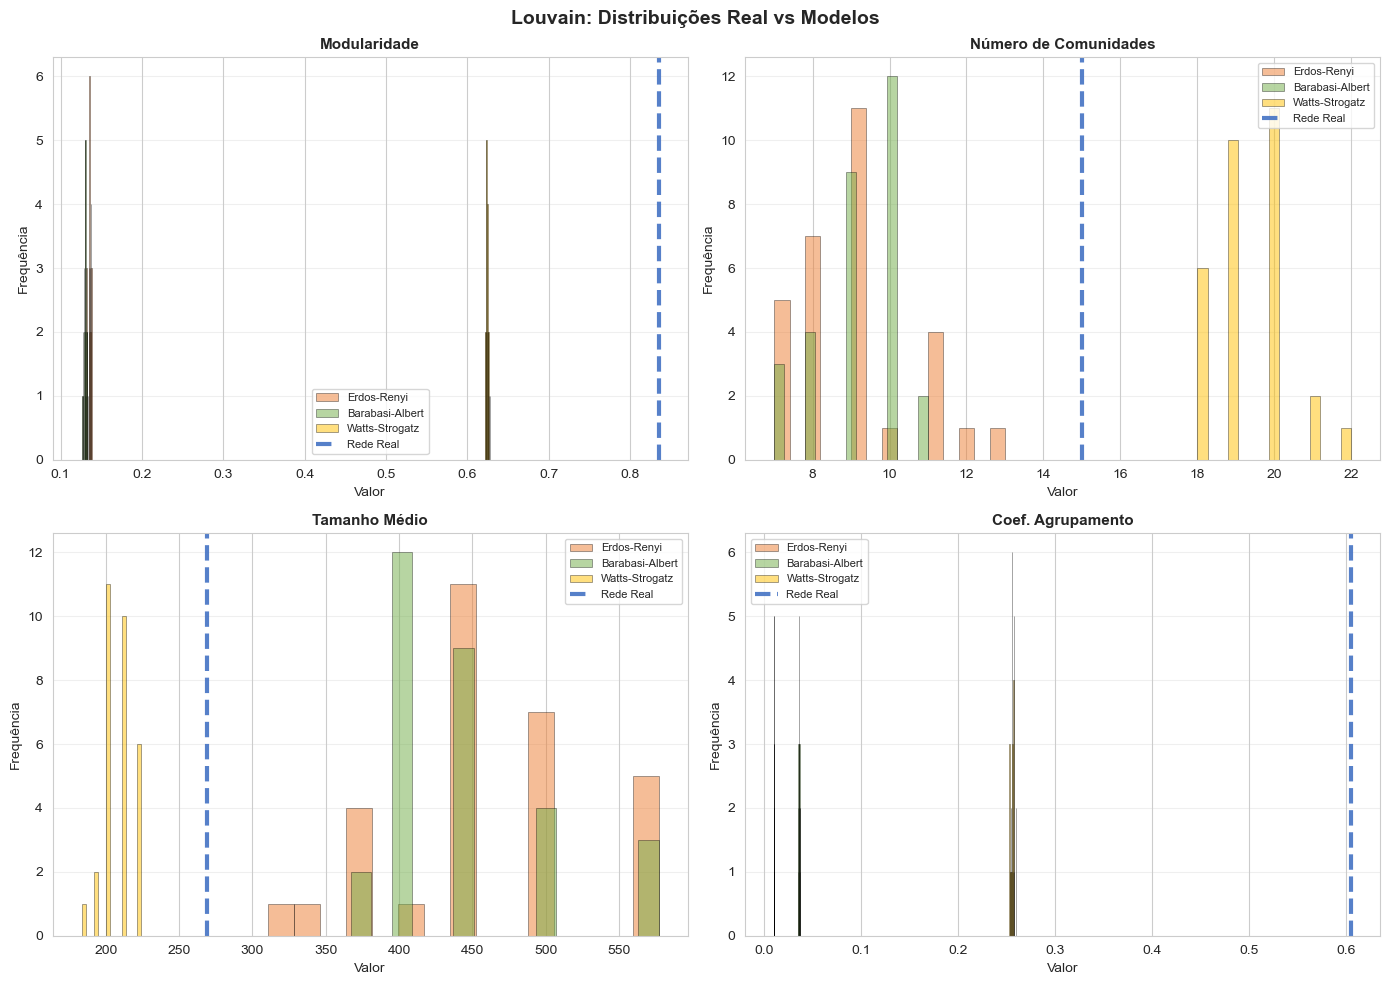

✓ Histograma salvo: Linha azul = Real, Histogramas = Modelos


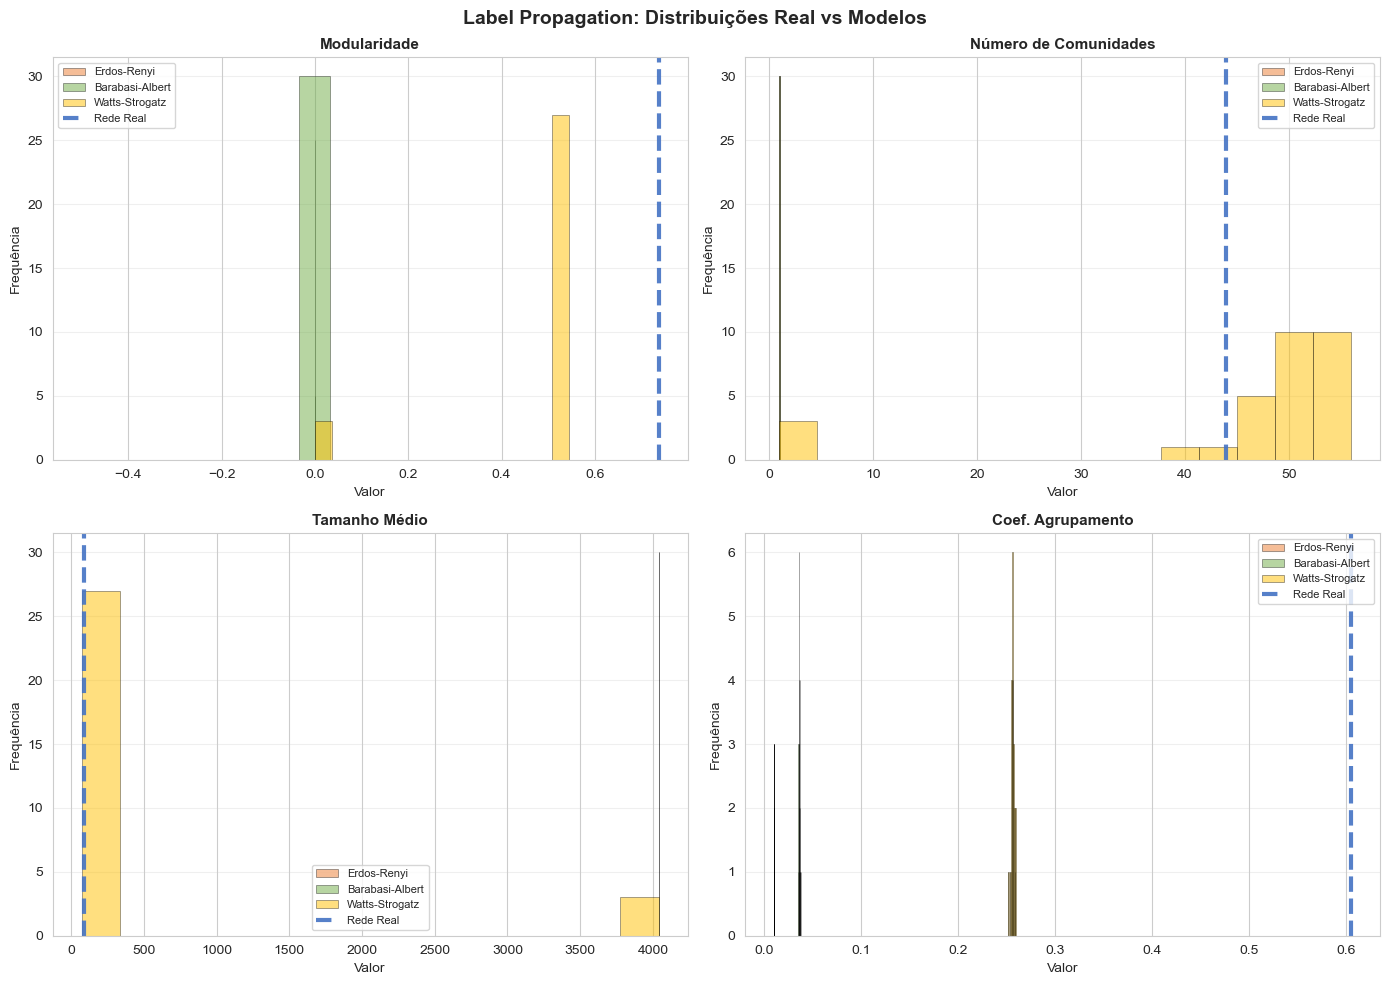

✓ Histograma salvo: Linha azul = Real, Histogramas = Modelos


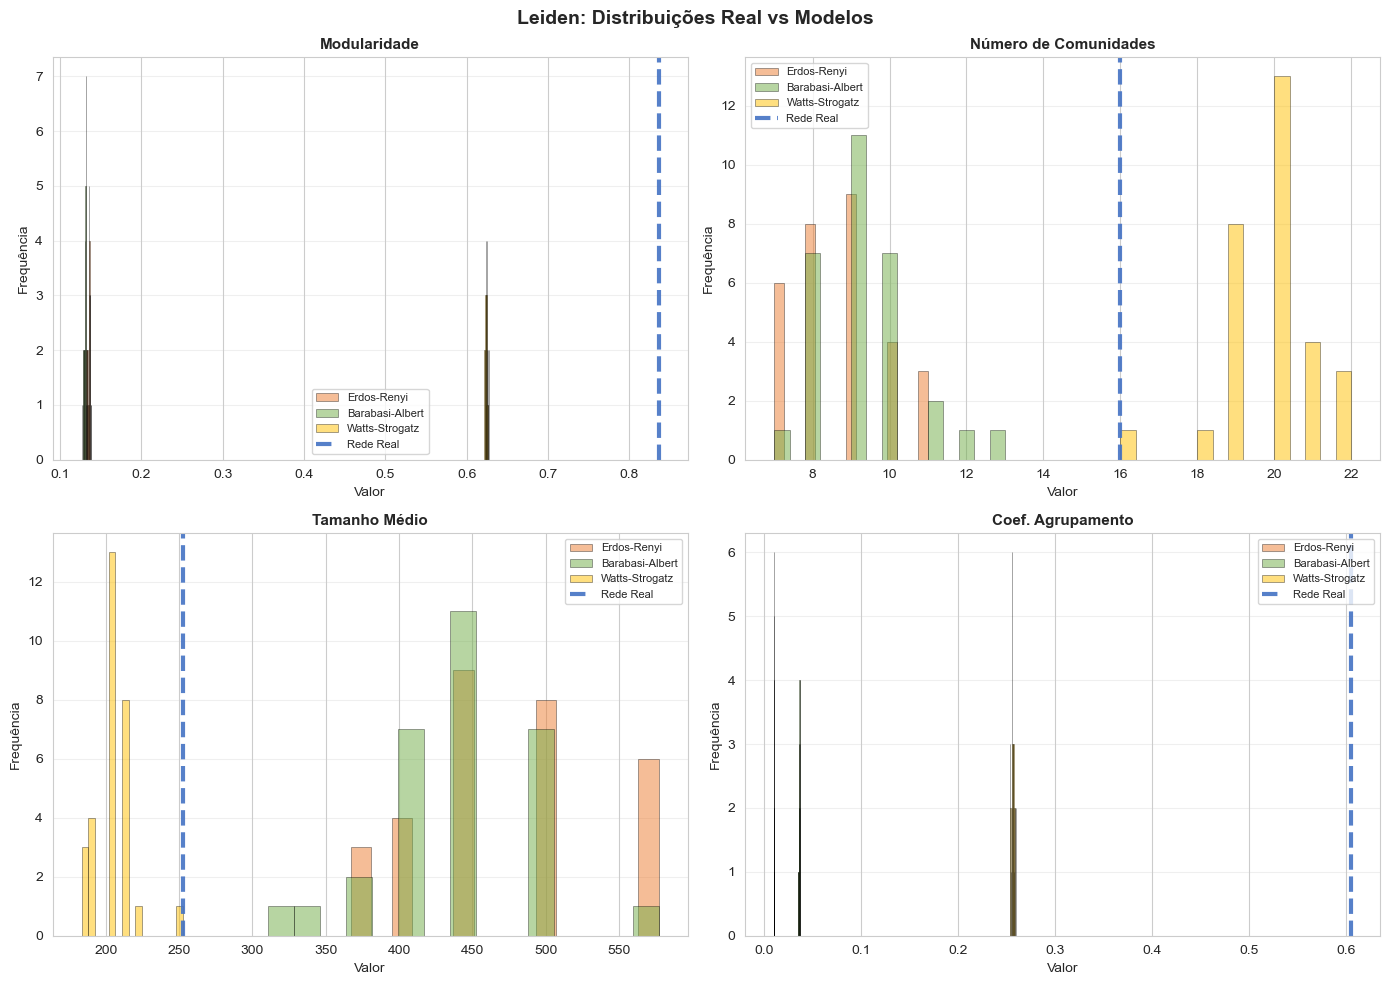

✓ Histograma salvo: Linha azul = Real, Histogramas = Modelos


In [5]:
# =============================
# PARTE 5: HISTOGRAMAS COMPARATIVOS
# =============================

print("\n" + "="*80)
print("PARTE 5: HISTOGRAMAS COMPARATIVOS DE DISTRIBUIÇÕES")
print("="*80)
print("""
OBJETIVO: Mostrar ONDE a REDE REAL se posiciona nas DISTRIBUIÇÕES dos modelos.

HISTOGRAMAS SOBREPOSTOS:
- Histogramas coloridos = Distribuição dos 30 experimentos de cada modelo
- Linha vertical azul tracejada = Valor da REDE REAL

INTERPRETAÇÃO:
- Se linha Real está no PICO do histograma: rede típica desse modelo
- Se está na CAUDA: rede é atípica/extrema para esse modelo
- Se está FORA de todos histogramas: rede tem propriedade única
- Sobreposição de histogramas: modelos produzem resultados similares
""")

def criar_histogramas_comparativos(resultados_completos):
    """Cria histogramas mostrando onde a rede real se posiciona"""
    
    for algorithm_name in ["Louvain", "Label Propagation", "Leiden"]:
        metricas_real = resultados_completos[algorithm_name]['real']
        experimentos = resultados_completos[algorithm_name]['modelos']
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()
        
        metricas_hist = [
            ('modularidade', 'Modularidade'),
            ('num_comunidades', 'Número de Comunidades'),
            ('tamanho_medio', 'Tamanho Médio'),
            ('coef_agrupamento', 'Coef. Agrupamento')
        ]
        
        cores_modelos = {
            'Erdos-Renyi': '#ED7D31',
            'Barabasi-Albert': '#70AD47', 
            'Watts-Strogatz': '#FFC000'
        }
        
        for idx, (metrica, titulo) in enumerate(metricas_hist):
            ax = axes[idx]
            
            # Histogramas dos modelos
            for modelo in ['Erdos-Renyi', 'Barabasi-Albert', 'Watts-Strogatz']:
                valores = [exp[metrica] for exp in experimentos[modelo]]
                ax.hist(valores, alpha=0.5, label=modelo, bins=15, 
                       color=cores_modelos[modelo], edgecolor='black', linewidth=0.5)
            
            # Linha da rede real
            valor_real = metricas_real[metrica]
            ax.axvline(valor_real, color='#4472C4', linestyle='--', linewidth=3, 
                      label='Rede Real', alpha=0.9)
            
            ax.set_title(titulo, fontsize=11, fontweight='bold')
            ax.set_xlabel('Valor', fontsize=10)
            ax.set_ylabel('Frequência', fontsize=10)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3, axis='y')
        
        plt.suptitle(f'{algorithm_name}: Distribuições Real vs Modelos', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'histogramas_{algorithm_name.replace(" ", "_")}.png', dpi=300)
        plt.show()
        
        print(f"✓ Histograma salvo: Linha azul = Real, Histogramas = Modelos")

criar_histogramas_comparativos(resultados_completos)

In [6]:
# =============================
# PARTE 6: TABELAS ESTATÍSTICAS DETALHADAS
# =============================

print("\n" + "="*80)
print("PARTE 6: TABELAS ESTATÍSTICAS DETALHADAS")
print("="*80)
print("""
OBJETIVO: Comparação QUANTITATIVA PRECISA entre REDE REAL e MODELOS.

TABELA:
- Coluna 1: Métrica analisada
- Coluna 2: Valor exato da REDE REAL
- Colunas 3-5: Média ± Desvio Padrão dos MODELOS (30 experimentos)

COMO USAR:
1. Compare valor Real com média do Modelo
2. Se |Real - Média| > 2×DP: diferença estatisticamente significativa
3. DP pequeno: modelo consistente; DP grande: modelo variável
""")

def criar_tabela_estatistica_detalhada(resultados_completos):
    """Cria tabela com estatísticas precisas Real vs Modelos"""
    
    for algorithm_name in ["Louvain", "Label Propagation", "Leiden"]:
        metricas_real = resultados_completos[algorithm_name]['real']
        experimentos = resultados_completos[algorithm_name]['modelos']
        
        print(f"\n{'='*80}")
        print(f"TABELA DETALHADA: {algorithm_name}")
        print(f"{'='*80}")
        
        dados_tabela = []
        
        metricas_exibir = [
            ('num_comunidades', 'Número de Comunidades', '0.0f'),
            ('tamanho_medio', 'Tamanho Médio', '2.2f'),
            ('grau_medio', 'Grau Médio', '2.2f'),
            ('densidade', 'Densidade', '4.4f'),
            ('coef_agrupamento', 'Coef. Agrupamento', '4.4f'),
            ('modularidade', 'Modularidade', '4.4f')
        ]
        
        for metrica_key, metrica_nome, formato in metricas_exibir:
            linha = {'Métrica': metrica_nome}
            
            # Rede Real
            if metrica_key in metricas_real:
                linha['Rede Real'] = f"{metricas_real[metrica_key]:{formato}}"
            else:
                linha['Rede Real'] = 'N/A'
            
            # Modelos
            for modelo in ['Erdos-Renyi', 'Barabasi-Albert', 'Watts-Strogatz']:
                if any(metrica_key in exp for exp in experimentos[modelo]):
                    valores = [exp.get(metrica_key, 0) for exp in experimentos[modelo]]
                    media = np.mean(valores)
                    std = np.std(valores)
                    linha[modelo] = f"{media:{formato}} ± {std:.4f}"
                else:
                    linha[modelo] = 'N/A'
            
            dados_tabela.append(linha)
        
        df = pd.DataFrame(dados_tabela)
        print("\n" + df.to_string(index=False))
        
        # Salvar CSV
        df.to_csv(f'tabela_detalhada_{algorithm_name.replace(" ", "_")}.csv', index=False)
        
        print(f"\n✓ Tabela salva: Compare valores Real vs Média±DP dos Modelos")

criar_tabela_estatistica_detalhada(resultados_completos)


PARTE 6: TABELAS ESTATÍSTICAS DETALHADAS

OBJETIVO: Comparação QUANTITATIVA PRECISA entre REDE REAL e MODELOS.

TABELA:
- Coluna 1: Métrica analisada
- Coluna 2: Valor exato da REDE REAL
- Colunas 3-5: Média ± Desvio Padrão dos MODELOS (30 experimentos)

COMO USAR:
1. Compare valor Real com média do Modelo
2. Se |Real - Média| > 2×DP: diferença estatisticamente significativa
3. DP pequeno: modelo consistente; DP grande: modelo variável


TABELA DETALHADA: Louvain

              Métrica Rede Real      Erdos-Renyi  Barabasi-Albert   Watts-Strogatz
Número de Comunidades        15       9 ± 1.5162       9 ± 1.0770      19 ± 0.9866
        Tamanho Médio    269.27 462.52 ± 72.7711 445.69 ± 57.4770 208.73 ± 10.4796
           Grau Médio     43.69   43.68 ± 0.1365   41.78 ± 0.0000   44.00 ± 0.0000
            Densidade    0.0108  0.0108 ± 0.0000  0.0103 ± 0.0000  0.0109 ± 0.0000
    Coef. Agrupamento    0.6055  0.0108 ± 0.0001  0.0365 ± 0.0005  0.2564 ± 0.0017
         Modularidade    0.8349 


PARTE 7: ANÁLISE DE ROBUSTEZ - REDE REAL

OBJETIVO: Avaliar a resiliência da topologia da rede frente a falhas e ataques.

METODOLOGIA DE ATAQUE (Remoção de Vértices):
A robustez é avaliada através da remoção iterativa de vértices seguindo critérios de prioridade.
Para cada estratégia, os vértices são ordenados de forma decrescente segundo a métrica:

1. ALEATÓRIO (Falhas):
   - Definição: Escolha estocástica uniforme de vértices.
   - Simulação: Representa falhas acidentais ou erros não intencionais.

2. GRAU (Degree Centrality - Ataque a Hubs):
   - Definição: Vértices com maior número de conexões diretas ($k$).
   - Impacto Esperado: Fragmentação rápida em redes livres de escala (Barabási-Albert).

3. INTERMEDIAÇÃO (Betweenness Centrality):
   - Definição: Vértices que aparecem com maior frequência nos caminhos geodésicos (caminhos mínimos)
     entre pares de outros nós.
   - Interpretação: Representam "pontes" ou controladores de fluxo de informação.

4. PROXIMIDADE (Closeness Ce

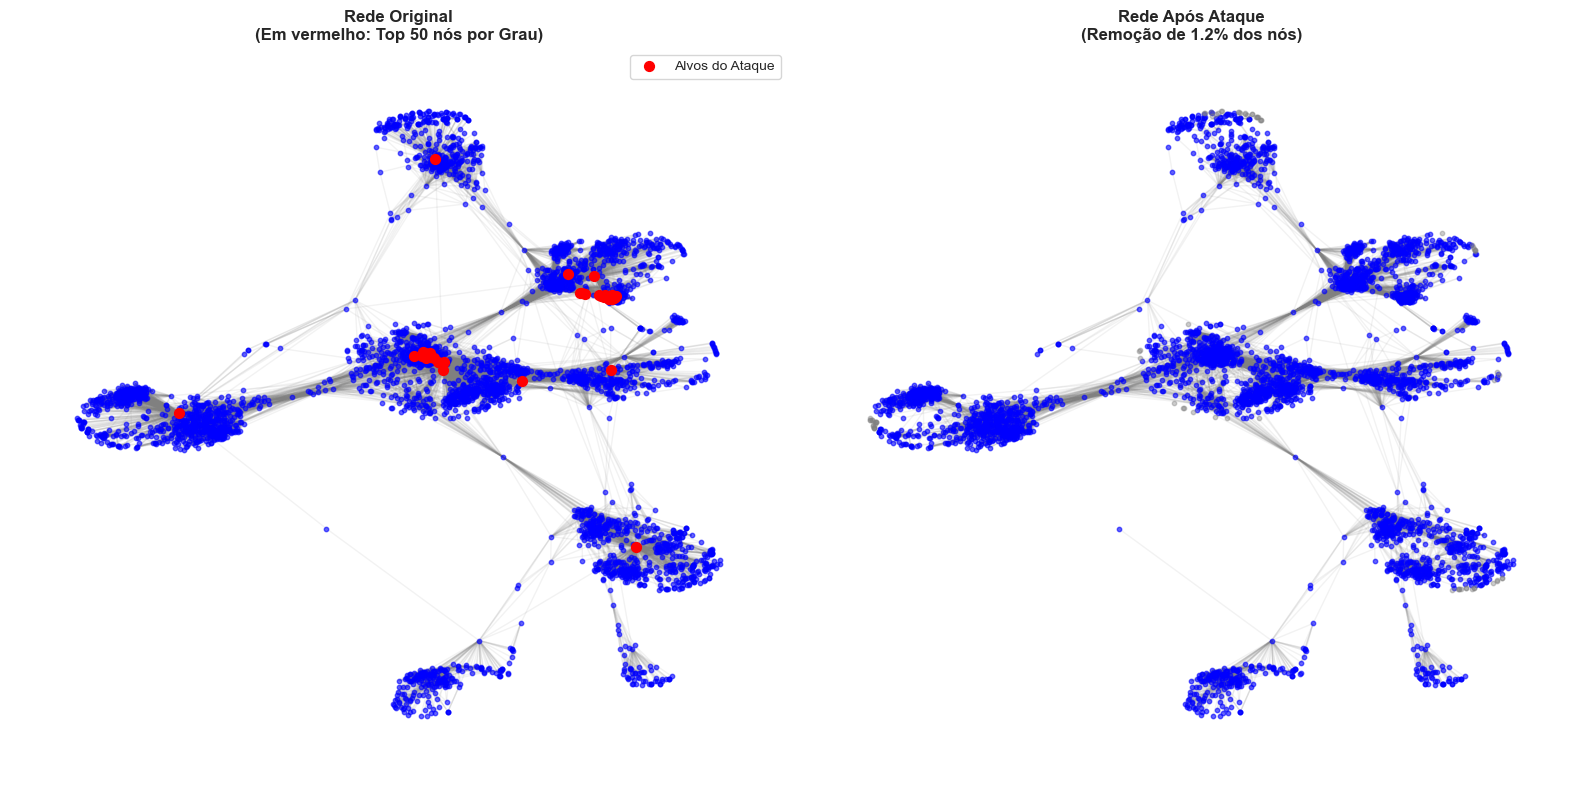

✓ Figura salva: visualizacao_ataque_Grau.png

Analisando robustez da REDE REAL para Louvain...
Parâmetros: Removendo 50 vértices (aprox. 1.24% da rede).
  - Processando estratégia: Aleatório...
  - Processando estratégia: Grau (Hubs)...
  - Processando estratégia: Intermediação...
  - Processando estratégia: Proximidade...


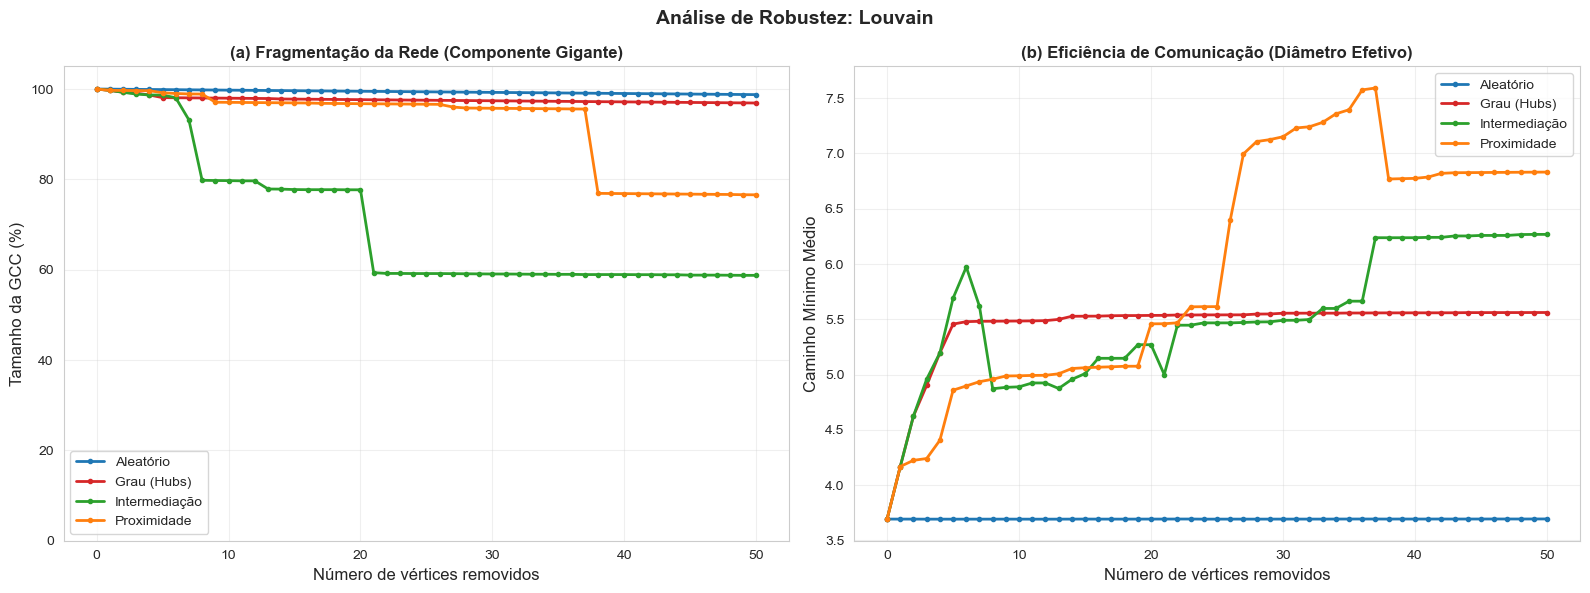

✓ Gráfico de robustez salvo: robustez_Louvain.png

Analisando robustez da REDE REAL para Label Propagation...
Parâmetros: Removendo 50 vértices (aprox. 1.24% da rede).
  - Processando estratégia: Aleatório...
  - Processando estratégia: Grau (Hubs)...
  - Processando estratégia: Intermediação...
  - Processando estratégia: Proximidade...


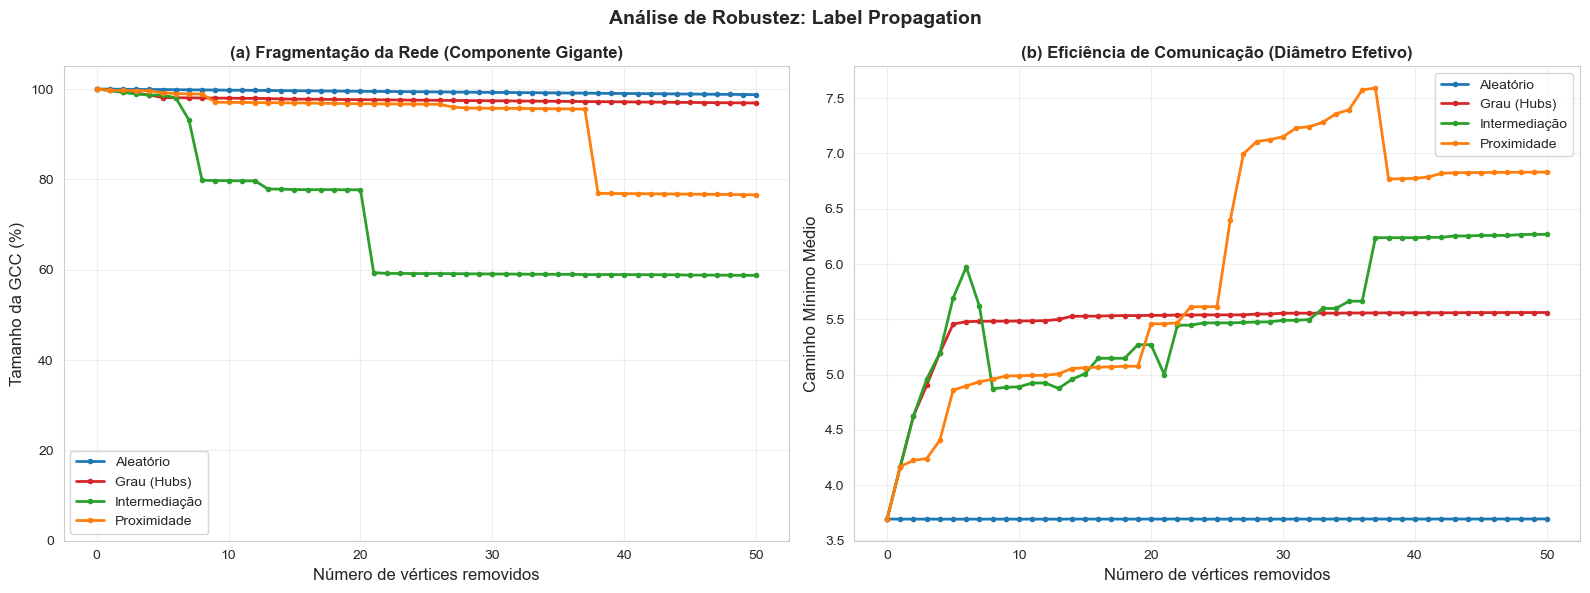

✓ Gráfico de robustez salvo: robustez_Label_Propagation.png

Analisando robustez da REDE REAL para Leiden...
Parâmetros: Removendo 50 vértices (aprox. 1.24% da rede).
  - Processando estratégia: Aleatório...
  - Processando estratégia: Grau (Hubs)...
  - Processando estratégia: Intermediação...
  - Processando estratégia: Proximidade...


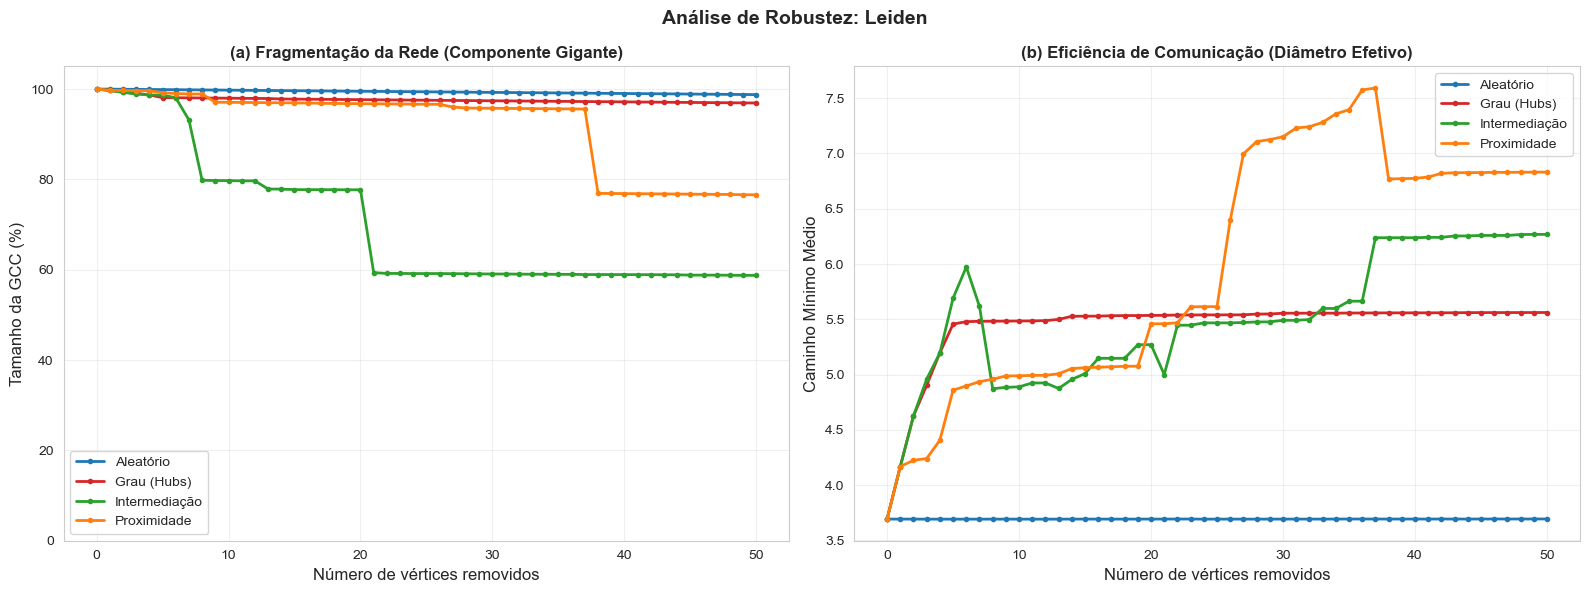

✓ Gráfico de robustez salvo: robustez_Leiden.png

PARTE 8: ANÁLISE DE ROBUSTEZ - MODELOS vs REDE REAL

OBJETIVO: Comparar a curva de degradação da REDE REAL contra os MODELOS TEÓRICOS.

HIPÓTESES DE TESTE:
1. Redes Aleatórias (Erdős-Rényi): Devem degradar lentamente, pois não possuem hubs estruturais.
2. Redes Livre de Escala (Barabási-Albert): Devem degradar muito rápido sob ataque a hubs, similar à rede real?
3. Redes Small-World (Watts-Strogatz): Comportamento intermediário.

METODOLOGIA:
- Ataque Direcionado por GRAU (Hubs) aplicado a todas as redes.
- Remoção progressiva dos top-k vértices mais conectados.


Comparando robustez: Real vs Modelos para Louvain...


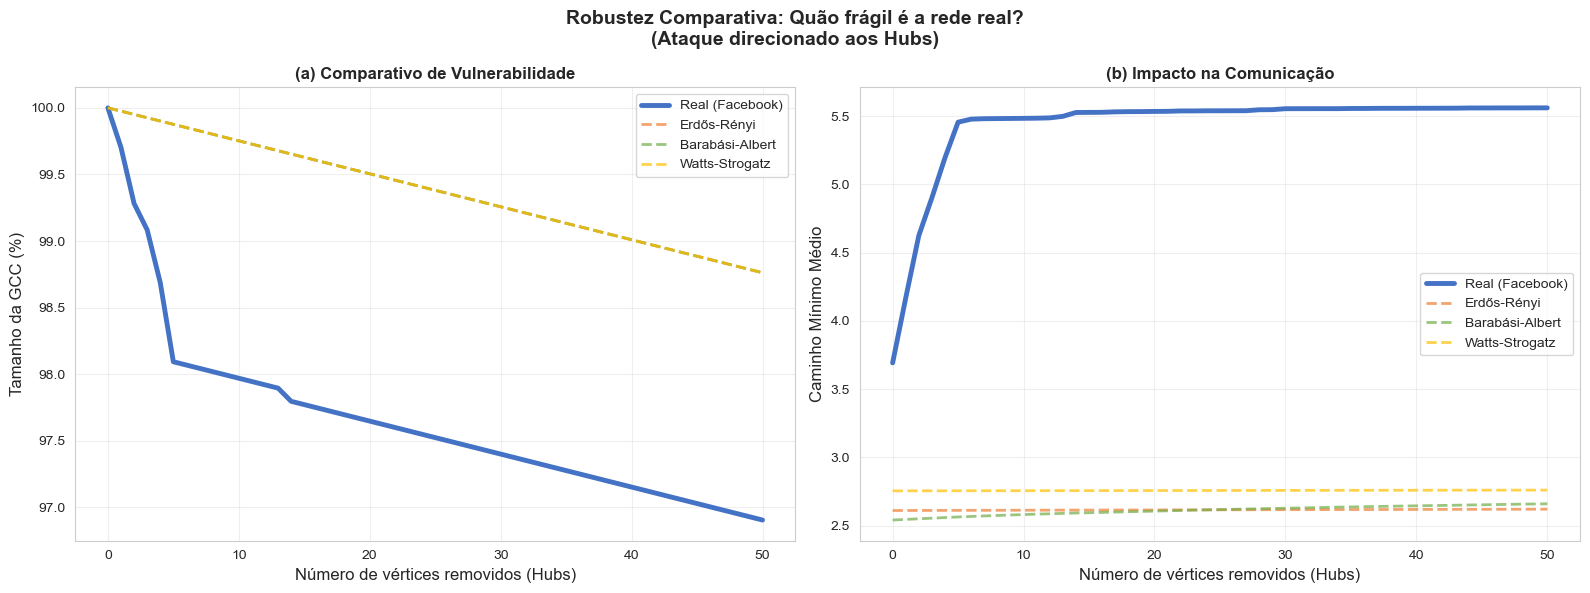

✓ Gráfico comparativo salvo: Real (sólido) vs Modelos (tracejado)

Comparando robustez: Real vs Modelos para Label Propagation...


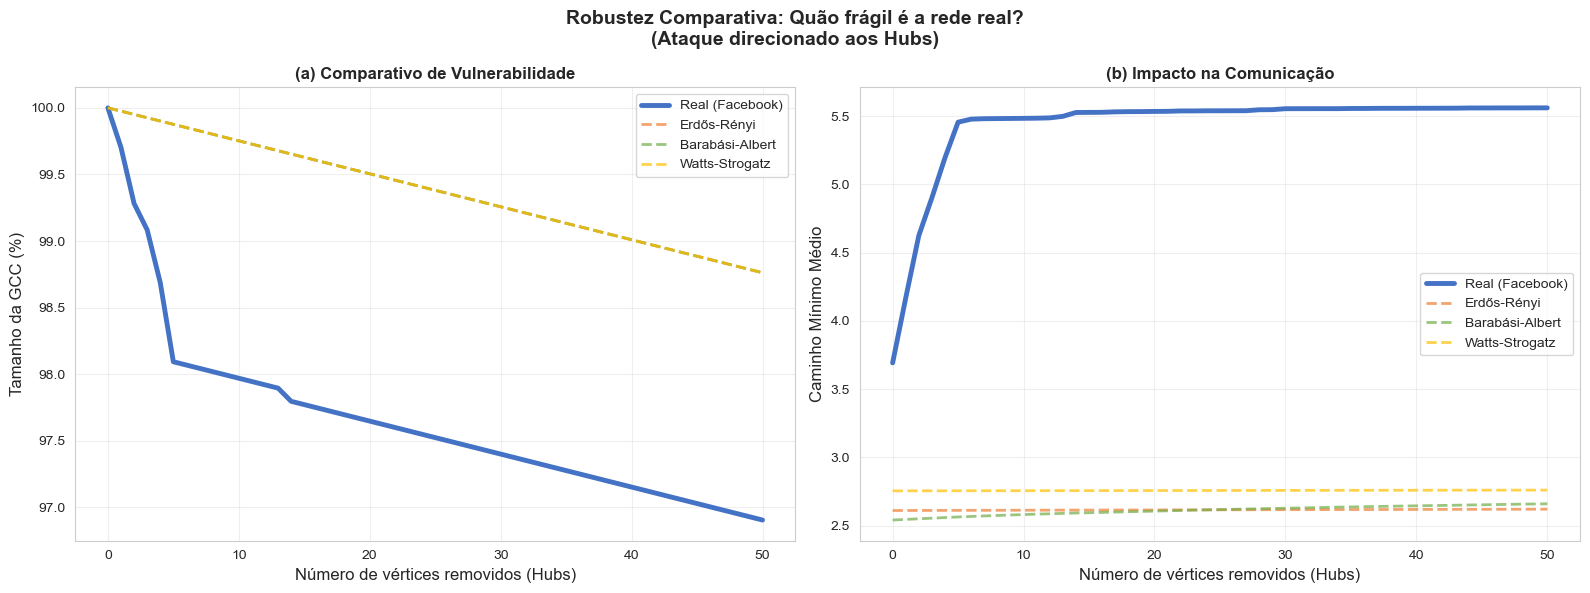

✓ Gráfico comparativo salvo: Real (sólido) vs Modelos (tracejado)

Comparando robustez: Real vs Modelos para Leiden...


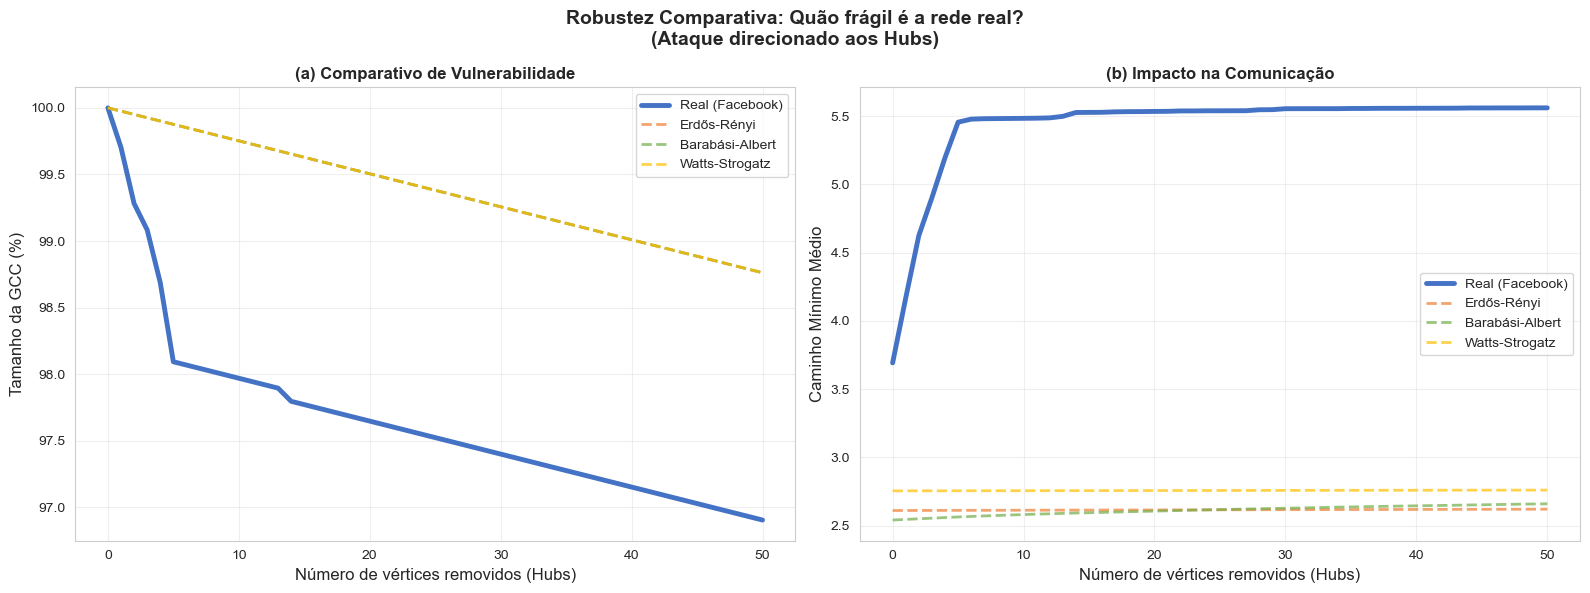

✓ Gráfico comparativo salvo: Real (sólido) vs Modelos (tracejado)

COMPARAÇÃO FINAL: RESUMO DOS TRÊS ALGORITMOS

        Algoritmo Modularidade  Nº Comunidades Tamanho Médio Coef. Agrupamento
          Louvain       0.8349              15        269.27            0.6055
Label Propagation       0.7368              44         91.80            0.6055
           Leiden       0.8358              16        252.44            0.6055

ANÁLISE COMPLETA FINALIZADA

ARQUIVOS GERADOS:

1. Visualizações de Comunidades (REDE REAL):
   - Facebook_louvain.png
   - Facebook_lpa.png
   - Facebook_leiden.png

2. Comparações Iniciais (REDE REAL):
   - Facebook_comparacao_modularidade_tempo.png
   - Facebook_distribuicao_comunidades.png

3. Box Plots (REAL vs MODELOS):
   - boxplots_Louvain.png
   - boxplots_Label_Propagation.png
   - boxplots_Leiden.png
   → Mostra: Onde REAL se posiciona nas distribuições dos MODELOS

4. Gráficos Comparativos (REAL vs MODELOS):
   - metricas_comparativas_Louvain.png
   - 

In [7]:
# =============================
# PARTE 7: ANÁLISE DE ROBUSTEZ - REDE REAL (CORRIGIDO E FORMALIZADO)
# =============================

print("\n" + "="*80)
print("PARTE 7: ANÁLISE DE ROBUSTEZ - REDE REAL")
print("="*80)

# Texto formalizado conforme pedido do orientador
print("""
OBJETIVO: Avaliar a resiliência da topologia da rede frente a falhas e ataques.

METODOLOGIA DE ATAQUE (Remoção de Vértices):
A robustez é avaliada através da remoção iterativa de vértices seguindo critérios de prioridade.
Para cada estratégia, os vértices são ordenados de forma decrescente segundo a métrica:

1. ALEATÓRIO (Falhas):
   - Definição: Escolha estocástica uniforme de vértices.
   - Simulação: Representa falhas acidentais ou erros não intencionais.

2. GRAU (Degree Centrality - Ataque a Hubs):
   - Definição: Vértices com maior número de conexões diretas ($k$).
   - Impacto Esperado: Fragmentação rápida em redes livres de escala (Barabási-Albert).

3. INTERMEDIAÇÃO (Betweenness Centrality):
   - Definição: Vértices que aparecem com maior frequência nos caminhos geodésicos (caminhos mínimos)
     entre pares de outros nós.
   - Interpretação: Representam "pontes" ou controladores de fluxo de informação.

4. PROXIMIDADE (Closeness Centrality):
   - Definição: Inverso da soma das distâncias de um vértice para todos os outros.
   - Interpretação: Vértices topologicamente centrais que disseminam informação com maior eficiência global.

MÉTRICAS DE DEGRADAÇÃO:
- Tamanho da Maior Componente Conexa (GCC): Percentual de nós que permanecem interconectados.
- Caminho Médio (LCC): Média das distâncias geodésicas na maior componente restante.
""")

def visualizar_exemplo_ataque(G, estrategia_nome, num_remocoes=50):
    """
    Gera uma figura 'Antes vs Depois' para atender ao pedido:
    'Mostra a cara do grafo antes e depois do ataque'.
    """
    print(f"\nGerando visualização visual do ataque: {estrategia_nome}...")
    
    # Preparar dados
    G_temp = G.copy()
    nodes = list(G_temp.nodes())
    
    # Selecionar nós a remover
    if estrategia_nome == 'Grau':
        nodes_sorted = sorted(nodes, key=lambda x: G_temp.degree(x), reverse=True)
        target_nodes = nodes_sorted[:num_remocoes]
    elif estrategia_nome == 'Betweenness':
        # Nota: Betweenness é lento em redes grandes, usando aproximação se necessário ou k fixo
        bc = nx.betweenness_centrality(G_temp, k=None) 
        nodes_sorted = sorted(nodes, key=lambda x: bc[x], reverse=True)
        target_nodes = nodes_sorted[:num_remocoes]
    else: # Aleatório
        np.random.seed(42)
        target_nodes = np.random.choice(nodes, num_remocoes, replace=False)

    # Configurar Layout Fixo (para ver o que sumiu no mesmo lugar)
    pos = nx.spring_layout(G_temp, seed=42, iterations=50) # Mais iterações para estabilizar
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot 1: Antes (Destacando os alvos)
    ax0 = axes[0]
    # Nós normais
    nx.draw_networkx_nodes(G_temp, pos, nodelist=[n for n in nodes if n not in target_nodes], 
                           node_size=10, node_color='blue', alpha=0.6, ax=ax0)
    # Nós alvo (Vermelho)
    nx.draw_networkx_nodes(G_temp, pos, nodelist=target_nodes, 
                           node_size=50, node_color='red', label='Alvos do Ataque', ax=ax0)
    nx.draw_networkx_edges(G_temp, pos, alpha=0.1, edge_color='gray', ax=ax0)
    ax0.set_title(f"Rede Original\n(Em vermelho: Top {num_remocoes} nós por {estrategia_nome})", fontweight='bold')
    ax0.legend()
    ax0.axis('off')
    
    # Plot 2: Depois
    G_temp.remove_nodes_from(target_nodes)
    ax1 = axes[1]
    
    # Identificar componente gigante restante
    if len(G_temp) > 0:
        gcc = max(nx.connected_components(G_temp), key=len)
        nodelist_gcc = list(gcc)
        nodelist_outros = [n for n in G_temp.nodes() if n not in gcc]
        
        # Desenhar GCC
        nx.draw_networkx_nodes(G_temp, pos, nodelist=nodelist_gcc, 
                               node_size=10, node_color='blue', alpha=0.6, ax=ax1)
        # Desenhar componentes desconectados (Cinza escuro)
        nx.draw_networkx_nodes(G_temp, pos, nodelist=nodelist_outros, 
                               node_size=10, node_color='gray', alpha=0.4, ax=ax1)
        nx.draw_networkx_edges(G_temp, pos, alpha=0.1, edge_color='gray', ax=ax1)
    
    percent_removed = (num_remocoes / len(nodes)) * 100
    ax1.set_title(f"Rede Após Ataque\n(Remoção de {percent_removed:.1f}% dos nós)", fontweight='bold')
    ax1.axis('off')
    
    plt.tight_layout()
    plt.savefig(f"visualizacao_ataque_{estrategia_nome}.png", dpi=300)
    plt.show()
    print(f"✓ Figura salva: visualizacao_ataque_{estrategia_nome}.png")


def analise_robustez_por_algoritmo(G, partition, algorithm_name, max_removals=50):
    """Analisa robustez da REDE REAL removendo nós"""
    
    n_total = G.number_of_nodes()
    percentual = (max_removals / n_total) * 100
    print(f"\nAnalisando robustez da REDE REAL para {algorithm_name}...")
    print(f"Parâmetros: Removendo {max_removals} vértices (aprox. {percentual:.2f}% da rede).")
    
    estrategias = {
        'Aleatório': 'random',
        'Grau (Hubs)': 'degree',
        'Intermediação': 'betweenness',
        'Proximidade': 'closeness'
    }
    
    resultados_robustez = {estrategia: {'tamanho_gcc': [], 'caminho_medio': []} 
                           for estrategia in estrategias.keys()}
    
    for estrategia_nome, estrategia_tipo in estrategias.items():
        print(f"  - Processando estratégia: {estrategia_nome}...")
        G_temp = G.copy()
        nodes = list(G_temp.nodes())
        
        # Ordenar nós conforme estratégia (Formality Upgrade)
        if estrategia_tipo == 'random':
            np.random.seed(42)
            np.random.shuffle(nodes)
        elif estrategia_tipo == 'degree':
            nodes = sorted(nodes, key=lambda x: G_temp.degree(x), reverse=True)
        elif estrategia_tipo == 'betweenness':
            # Otimização: Betweenness é muito pesado para calcular a cada passo
            # Calculamos uma vez no início (Ataque Estático)
            bc = nx.betweenness_centrality(G_temp)
            nodes = sorted(nodes, key=lambda x: bc[x], reverse=True)
        elif estrategia_tipo == 'closeness':
            cc = nx.closeness_centrality(G_temp)
            nodes = sorted(nodes, key=lambda x: cc[x], reverse=True)
        
        # Remover nós progressivamente
        for i in range(min(max_removals + 1, len(nodes))):
            if i > 0:
                G_temp.remove_node(nodes[i-1])
            
            # Métricas da GCC
            if G_temp.number_of_nodes() > 0:
                # Encontrar Maior Componente Conexa (Giant Component)
                connected_components = list(nx.connected_components(G_temp))
                if connected_components:
                    gcc_nodes = max(connected_components, key=len)
                    gcc = G_temp.subgraph(gcc_nodes).copy()
                    
                    # 1. Tamanho Relativo da GCC
                    tamanho_gcc = gcc.number_of_nodes() / G.number_of_nodes() * 100
                    resultados_robustez[estrategia_nome]['tamanho_gcc'].append(tamanho_gcc)
                    
                    # 2. Caminho Médio (apenas se tiver nós suficientes)
                    if gcc.number_of_nodes() > 1:
                        try:
                            # Otimização: Usar sample se a rede for muito grande, aqui faremos exato
                            caminho = nx.average_shortest_path_length(gcc)
                            resultados_robustez[estrategia_nome]['caminho_medio'].append(caminho)
                        except:
                            resultados_robustez[estrategia_nome]['caminho_medio'].append(0)
                    else:
                        resultados_robustez[estrategia_nome]['caminho_medio'].append(0)
                else:
                    resultados_robustez[estrategia_nome]['tamanho_gcc'].append(0)
                    resultados_robustez[estrategia_nome]['caminho_medio'].append(0)
            else:
                resultados_robustez[estrategia_nome]['tamanho_gcc'].append(0)
                resultados_robustez[estrategia_nome]['caminho_medio'].append(0)
    
    return resultados_robustez

def plotar_analise_robustez(resultados_robustez, algorithm_name, tipo='real'):
    """Plota gráficos de robustez"""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Cores consistentes
    cores = {
        'Aleatório': '#1f77b4',       # Azul
        'Grau (Hubs)': '#d62728',     # Vermelho (Alerta)
        'Intermediação': '#2ca02c',   # Verde
        'Proximidade': '#ff7f0e'      # Laranja
    }
    
    # (a) Tamanho da componente gigante
    ax = axes[0]
    for estrategia, dados in resultados_robustez.items():
        if len(dados['tamanho_gcc']) > 0:
            x = range(len(dados['tamanho_gcc']))
            ax.plot(x, dados['tamanho_gcc'], marker='o', markersize=3, 
                    label=estrategia, color=cores.get(estrategia, 'gray'), linewidth=2)
    
    ax.set_xlabel('Número de vértices removidos', fontsize=12)
    ax.set_ylabel('Tamanho da GCC (%)', fontsize=12)
    ax.set_title('(a) Fragmentação da Rede (Componente Gigante)', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 105])
    
    # (b) Caminho médio
    ax = axes[1]
    for estrategia, dados in resultados_robustez.items():
        if len(dados['caminho_medio']) > 0:
            x = range(len(dados['caminho_medio']))
            ax.plot(x, dados['caminho_medio'], marker='o', markersize=3,
                   label=estrategia, color=cores.get(estrategia, 'gray'), linewidth=2)
    
    ax.set_xlabel('Número de vértices removidos', fontsize=12)
    ax.set_ylabel('Caminho Mínimo Médio', fontsize=12)
    ax.set_title('(b) Eficiência de Comunicação (Diâmetro Efetivo)', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    titulo = f'Análise de Robustez: {algorithm_name}' if tipo == 'real' else f'Robustez Modelos: {algorithm_name}'
    plt.suptitle(titulo, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    filename = f'robustez_{algorithm_name.replace(" ", "_")}.png' if tipo == 'real' else f'robustez_modelos_{algorithm_name.replace(" ", "_")}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Gráfico de robustez salvo: {filename}")

# --- EXECUÇÃO DA PARTE 7 ---

# 1. Visualização "Antes e Depois" (Pedido do Orientador - Exemplo com Grau)
visualizar_exemplo_ataque(G_FB, "Grau", num_remocoes=50)

# 2. Análise quantitativa completa
for algorithm_name, partition in algoritmos_analise:
    resultados_robustez = analise_robustez_por_algoritmo(G_FB, partition, algorithm_name, max_removals=50)
    plotar_analise_robustez(resultados_robustez, algorithm_name, tipo='real')


# =============================
# PARTE 8: ANÁLISE DE ROBUSTEZ - MODELOS SINTÉTICOS (COMPARATIVO)
# =============================
print("\n" + "="*80)
print("PARTE 8: ANÁLISE DE ROBUSTEZ - MODELOS vs REDE REAL")
print("="*80)
print("""
OBJETIVO: Comparar a curva de degradação da REDE REAL contra os MODELOS TEÓRICOS.

HIPÓTESES DE TESTE:
1. Redes Aleatórias (Erdős-Rényi): Devem degradar lentamente, pois não possuem hubs estruturais.
2. Redes Livre de Escala (Barabási-Albert): Devem degradar muito rápido sob ataque a hubs, similar à rede real?
3. Redes Small-World (Watts-Strogatz): Comportamento intermediário.

METODOLOGIA:
- Ataque Direcionado por GRAU (Hubs) aplicado a todas as redes.
- Remoção progressiva dos top-k vértices mais conectados.
""")

def analise_robustez_modelos(G_real, algorithm_name, max_removals=50):
    """Compara robustez da REDE REAL com MODELOS"""
    
    print(f"\nComparando robustez: Real vs Modelos para {algorithm_name}...")
    
    n_nodes = G_real.number_of_nodes()
    n_edges = G_real.number_of_edges()
    
    # Parâmetros calculados dinamicamente (Formalidade exigida)
    p_er = (2 * n_edges) / (n_nodes * (n_nodes - 1))
    m_ba = int(n_edges / n_nodes)
    k_ws = int(2 * n_edges / n_nodes)
    if k_ws % 2 != 0: k_ws += 1
    p_ws = 0.3
    
    # Gerar um grafo representativo de cada modelo
    G_er = nx.erdos_renyi_graph(n_nodes, p_er, seed=42)
    G_ba = nx.barabasi_albert_graph(n_nodes, m_ba, seed=42)
    G_ws = nx.watts_strogatz_graph(n_nodes, k_ws, p_ws, seed=42)
    
    grafos = {
        'Real (Facebook)': G_real,
        'Erdős-Rényi': G_er,
        'Barabási-Albert': G_ba,
        'Watts-Strogatz': G_ws
    }
    
    # Analisar robustez por grau (ataque direcionado)
    resultados_comparativos = {}
    
    for nome_grafo, G_atual in grafos.items():
        G_temp = G_atual.copy()
        nodes = list(G_temp.nodes())
        # Ataque por Grau (Hubs)
        nodes_sorted = sorted(nodes, key=lambda x: G_temp.degree(x), reverse=True)
        
        tamanhos_gcc = []
        caminhos_medios = []
        
        for i in range(min(max_removals + 1, len(nodes_sorted))):
            if i > 0:
                G_temp.remove_node(nodes_sorted[i-1])
            
            if G_temp.number_of_nodes() > 0:
                if nx.is_connected(G_temp):
                    gcc = G_temp
                else:
                    if len(list(nx.connected_components(G_temp))) > 0:
                        gcc = G_temp.subgraph(max(nx.connected_components(G_temp), key=len)).copy()
                    else:
                        continue
                
                tamanho = gcc.number_of_nodes() / G_atual.number_of_nodes() * 100
                tamanhos_gcc.append(tamanho)
                
                if gcc.number_of_nodes() > 1:
                    try:
                        # Cálculo aproximado para performance se necessário, aqui exato
                        if nx.is_connected(gcc):
                            caminho = nx.average_shortest_path_length(gcc)
                            caminhos_medios.append(caminho)
                        else:
                            caminhos_medios.append(0)
                    except:
                        caminhos_medios.append(0)
                else:
                    caminhos_medios.append(0)
        
        resultados_comparativos[nome_grafo] = {
            'tamanho_gcc': tamanhos_gcc,
            'caminho_medio': caminhos_medios
        }
    
    return resultados_comparativos

def plotar_robustez_comparativa(resultados_comp, algorithm_name):
    """Plota comparação de robustez: Real vs Modelos"""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    cores = {
        'Real (Facebook)': '#4472C4',  # Azul forte
        'Erdős-Rényi': '#ED7D31',      # Laranja
        'Barabási-Albert': '#70AD47',  # Verde
        'Watts-Strogatz': '#FFC000'    # Amarelo
    }
    
    # (a) Tamanho da componente gigante
    ax = axes[0]
    for nome, dados in resultados_comp.items():
        if len(dados['tamanho_gcc']) > 0:
            x = range(len(dados['tamanho_gcc']))
            # Destaque para a rede real
            linewidth = 3.5 if 'Real' in nome else 2
            linestyle = '-' if 'Real' in nome else '--'
            alpha = 1.0 if 'Real' in nome else 0.7
            
            ax.plot(x, dados['tamanho_gcc'], marker=None, 
                    label=nome, color=cores.get(nome, 'gray'), 
                    linewidth=linewidth, linestyle=linestyle, alpha=alpha)
    
    ax.set_xlabel('Número de vértices removidos (Hubs)', fontsize=12)
    ax.set_ylabel('Tamanho da GCC (%)', fontsize=12)
    ax.set_title('(a) Comparativo de Vulnerabilidade', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # (b) Caminho médio
    ax = axes[1]
    for nome, dados in resultados_comp.items():
        if len(dados['caminho_medio']) > 0:
            x = range(len(dados['caminho_medio']))
            linewidth = 3.5 if 'Real' in nome else 2
            linestyle = '-' if 'Real' in nome else '--'
            alpha = 1.0 if 'Real' in nome else 0.7
            
            ax.plot(x, dados['caminho_medio'], marker=None,
                   label=nome, color=cores.get(nome, 'gray'),
                   linewidth=linewidth, linestyle=linestyle, alpha=alpha)
    
    ax.set_xlabel('Número de vértices removidos (Hubs)', fontsize=12)
    ax.set_ylabel('Caminho Mínimo Médio', fontsize=12)
    ax.set_title('(b) Impacto na Comunicação', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Robustez Comparativa: Quão frágil é a rede real?\n(Ataque direcionado aos Hubs)', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'robustez_comparativa_{algorithm_name.replace(" ", "_")}.png', dpi=300)
    plt.show()
    
    print(f"✓ Gráfico comparativo salvo: Real (sólido) vs Modelos (tracejado)")

# Executar análise comparativa
for algorithm_name, partition in algoritmos_analise:
    resultados_comp = analise_robustez_modelos(G_FB, algorithm_name, max_removals=50)
    plotar_robustez_comparativa(resultados_comp, algorithm_name)

# =============================
# COMPARAÇÃO FINAL E CONCLUSÕES
# =============================
print("\n" + "="*80)
print("COMPARAÇÃO FINAL: RESUMO DOS TRÊS ALGORITMOS")
print("="*80)

resumo_data = []
for alg_name in ["Louvain", "Label Propagation", "Leiden"]:
    metricas = resultados_completos[alg_name]['real']
    resumo_data.append({
        'Algoritmo': alg_name,
        'Modularidade': f"{metricas['modularidade']:.4f}",
        'Nº Comunidades': int(metricas['num_comunidades']),
        'Tamanho Médio': f"{metricas['tamanho_medio']:.2f}",
        'Coef. Agrupamento': f"{metricas['coef_agrupamento']:.4f}"
    })

df_resumo = pd.DataFrame(resumo_data)
print("\n" + df_resumo.to_string(index=False))
df_resumo.to_csv('resumo_comparacao_algoritmos.csv', index=False)

print("\n" + "="*80)
print("ANÁLISE COMPLETA FINALIZADA")
print("="*80)
print("\nARQUIVOS GERADOS:")
print("\n1. Visualizações de Comunidades (REDE REAL):")
print("   - Facebook_louvain.png")
print("   - Facebook_lpa.png")
print("   - Facebook_leiden.png")
print("\n2. Comparações Iniciais (REDE REAL):")
print("   - Facebook_comparacao_modularidade_tempo.png")
print("   - Facebook_distribuicao_comunidades.png")
print("\n3. Box Plots (REAL vs MODELOS):")
print("   - boxplots_Louvain.png")
print("   - boxplots_Label_Propagation.png")
print("   - boxplots_Leiden.png")
print("   → Mostra: Onde REAL se posiciona nas distribuições dos MODELOS")
print("\n4. Gráficos Comparativos (REAL vs MODELOS):")
print("   - metricas_comparativas_Louvain.png")
print("   - metricas_comparativas_Label_Propagation.png")
print("   - metricas_comparativas_Leiden.png")
print("   → Mostra: Diferenças absolutas entre REAL e MODELOS")
print("\n5. Histogramas (REAL vs MODELOS):")
print("   - histogramas_Louvain.png")
print("   - histogramas_Label_Propagation.png")
print("   - histogramas_Leiden.png")
print("   → Mostra: Distribuições dos MODELOS com linha REAL")
print("\n6. Análise de Robustez (REDE REAL):")
print("   - robustez_Louvain.png")
print("   - robustez_Label_Propagation.png")
print("   - robustez_Leiden.png")
print("   → Mostra: Como REDE REAL resiste a remoções")
print("\n7. Análise de Robustez Comparativa (REAL vs MODELOS):")
print("   - robustez_comparativa_Louvain.png")
print("   - robustez_comparativa_Label_Propagation.png")
print("   - robustez_comparativa_Leiden.png")
print("   → Mostra: REAL (sólido) vs MODELOS (tracejado)")
print("\n8. Tabelas CSV (REAL vs MODELOS):")
print("   - tabela_Louvain.csv")
print("   - tabela_Label_Propagation.csv")
print("   - tabela_Leiden.csv")
print("   - tabela_detalhada_Louvain.csv")
print("   - tabela_detalhada_Label_Propagation.csv")
print("   - tabela_detalhada_Leiden.csv")
print("   - resumo_comparacao_algoritmos.csv")
print("   → Contém: Valores REAL e Média±DP dos MODELOS")

print("\n" + "="*80)
print("INTERPRETAÇÃO GERAL:")
print("="*80)
print("""
Para cada algoritmo (Louvain, Label Propagation, Leiden):

1. BOX PLOTS: Mostram se a REDE REAL é típica ou atípica dos MODELOS
   - Estrela dentro da caixa = comportamento esperado
   - Estrela fora = propriedade única da rede real

2. GRÁFICOS DE BARRAS: Comparam valores absolutos
   - Compare altura da barra Real vs Modelos
   - Barras de erro grandes = modelo inconsistente

3. HISTOGRAMAS: Mostram onde Real está nas distribuições
   - Linha no pico = típico do modelo
   - Linha na cauda ou fora = atípico

4. TABELAS: Permitem comparação numérica precisa
   - |Real - Média| > 2×DP = diferença significativa

5. ROBUSTEZ REAL: Mostra vulnerabilidades da rede
   - Queda rápida em "Grau" = vulnerável a ataques direcionados
   - Queda lenta em "Aleatório" = robusto a falhas aleatórias

6. ROBUSTEZ COMPARATIVA: Compara resiliência Real vs Modelos
   - Real degrada mais rápido = mais vulnerável que modelos teóricos
   - Real degrada mais lento = mais robusto que esperado
""")
print("="*80)